# CRI_TS Empirical Validation on CausalChamber Wind Tunnel

This notebook runs the full experimental pipeline:
1. **Step 1**: Load wind tunnel data & ground truth
2. **Step 2**: Run PCMCI+ with multiple CI tests (RobustParCorr, GPDC, CMIknn)
3. **Step 3**: Compute CRI_TS, standard metrics, and generate all plots

---
### 0. Install dependencies

In [1]:
import sys, subprocess
pkgs = ["causalchamber", "tigramite", "numpy", "pandas", "matplotlib",
        "seaborn", "networkx", "scikit-learn", "dcor"]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("All packages installed.")

All packages installed.


---
## 1. Load Data & Ground Truth

In [16]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "outputs"
DATA_DIR   = "data"
RESULTS_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [17]:
import causalchamber.datasets as ccd

DATASET_NAME    = "wt_walks_v1"
EXPERIMENT_NAME = "actuators_random_walk_1"

print(f"Downloading dataset '{DATASET_NAME}'...")
dataset = ccd.Dataset(name=DATASET_NAME, root=DATA_DIR, download=True)

print(f"Loading experiment '{EXPERIMENT_NAME}'...")
experiment = dataset.get_experiment(name=EXPERIMENT_NAME)
df_full = experiment.as_pandas_dataframe()

print(f"Shape: {df_full.shape}")
print(f"Columns: {list(df_full.columns)}")
df_full.head()

Dataset wt_walks_v1 found in "data\wt_walks_v1".
Loading experiment 'actuators_random_walk_1'...
Shape: (1016, 37)
Columns: ['timestamp', 'config', 'counter', 'flag', 'intervention', 'hatch', 'pot_1', 'pot_2', 'osr_1', 'osr_2', 'osr_mic', 'osr_in', 'osr_out', 'osr_upwind', 'osr_downwind', 'osr_ambient', 'osr_intake', 'v_1', 'v_2', 'v_mic', 'v_in', 'v_out', 'load_in', 'load_out', 'current_in', 'current_out', 'res_in', 'res_out', 'rpm_in', 'rpm_out', 'pressure_upwind', 'pressure_downwind', 'pressure_ambient', 'pressure_intake', 'mic', 'signal_1', 'signal_2']


,timestamp,config,counter,flag,intervention,hatch,pot_1,pot_2,osr_1,osr_2,...,res_out,rpm_in,rpm_out,pressure_upwind,pressure_downwind,pressure_ambient,pressure_intake,mic,signal_1,signal_2
0,10375.354285,standard,0.0,-9999.0,1.0,39.579998,145.110001,222.720001,1.0,1.0,...,1.0,753.541626,848.224365,96790.273438,96779.210938,96780.554688,96777.578125,253.0,3.0,49.0
1,10375.571266,standard,1.0,-9999.0,1.0,39.369999,147.220001,225.440002,1.0,1.0,...,1.0,716.127197,979.623840,96790.273438,96778.460938,96780.789062,96777.531250,36.0,0.0,51.0
2,10375.800483,standard,2.0,-9999.0,1.0,39.149998,148.330002,226.159988,1.0,1.0,...,1.0,704.887207,1143.292725,96790.023438,96777.734375,96780.664062,96777.367188,35.0,0.0,52.0
3,10376.116116,standard,3.0,-9999.0,1.0,39.139999,148.440002,228.889999,1.0,1.0,...,1.0,741.839783,1373.626343,96789.343750,96777.226562,96780.734375,96777.578125,108.0,58.0,52.0
4,10376.333799,standard,4.0,-9999.0,1.0,39.219997,149.550003,226.610001,1.0,1.0,...,1.0,793.147217,1525.010132,96789.328125,96776.226562,96781.156250,96778.031250,36.0,5.0,2.0


### Ground truth from the paper

From Gamella et al. (2024), Fig. 3 and Appendix III, the wind tunnel has these causal edges among our 6 selected variables (mic excluded due to non-stationarity):

```
load_in  -->  rpm_in
load_out -->  rpm_out
rpm_in   -->  pressure_downwind
rpm_out  -->  pressure_downwind
pressure_ambient --> pressure_downwind
```


In [18]:
# loading ground truth from the package
try:
    import causalchamber.ground_truth as ccgt
    print(f"ground_truth module available. Contents: {dir(ccgt)}")
    # Try to load it
    try:
        gt = ccgt.graph("wind_tunnel")
        print(f"Loaded ground truth: {type(gt)}")
        if hasattr(gt, 'edges'):
            print(f"Edges: {list(gt.edges())}")
        if hasattr(gt, 'nodes'):
            print(f"Nodes: {list(gt.nodes())}")
    except Exception as e:
        print(f"Could not load: {e}")
except ImportError:
    print("ground_truth module not available")

ground_truth module available. Contents: ['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'graph', 'latex_name', 'main']
Could not load: graph() missing 1 required positional argument: 'configuration'


In [19]:
SELECTED_VARS = [
    "load_in",             # L_in:   intake fan load (actuator)
    "load_out",            # L_out:  exhaust fan load (actuator)
    "rpm_in",              # V_in:   intake fan speed (RPM sensor)
    "rpm_out",             # V_out:  exhaust fan speed (RPM sensor)
    "pressure_downwind",   # P_dw:   downwind pressure (sensor)
    "pressure_ambient",    # P_amb:  ambient/barometric pressure (sensor)
]

# Check they exist
available_vars = [v for v in SELECTED_VARS if v in df_full.columns]
missing = [v for v in SELECTED_VARS if v not in df_full.columns]
if missing:
    print(f"WARNING: Missing variables: {missing}")
    print(f"Available columns: {sorted(df_full.columns.tolist())}")
print(f"Using ({len(available_vars)}): {available_vars}")

# Ground truth edges from the paper (Fig. 3, Appendix III)
# mic removed — non-stationary and excluded from this experiment
GT_EDGES = [
    ("load_in", "rpm_in"),
    ("load_out", "rpm_out"),
    ("rpm_in", "pressure_downwind"),
    ("rpm_out", "pressure_downwind"),
    ("pressure_ambient", "pressure_downwind"),
]
GT_EDGES = [(s, t) for s, t in GT_EDGES if s in available_vars and t in available_vars]


Using (6): ['load_in', 'load_out', 'rpm_in', 'rpm_out', 'pressure_downwind', 'pressure_ambient']


In [20]:

# Build adjacency matrix
n_vars = len(available_vars)
gt_adj = np.zeros((n_vars, n_vars), dtype=int)
for src, tgt in GT_EDGES:
    gt_adj[available_vars.index(src), available_vars.index(tgt)] = 1

print(f"\nGround truth edges ({len(GT_EDGES)}):")
for s, t in GT_EDGES:
    print(f"  {s} --> {t}")
print(f"\nAdjacency matrix:")
pd.DataFrame(gt_adj, index=available_vars, columns=available_vars)


Ground truth edges (5):
  load_in --> rpm_in
  load_out --> rpm_out
  rpm_in --> pressure_downwind
  rpm_out --> pressure_downwind
  pressure_ambient --> pressure_downwind

Adjacency matrix:


,load_in,load_out,rpm_in,rpm_out,pressure_downwind,pressure_ambient
load_in,0,0,1,0,0,0
load_out,0,0,0,1,0,0
rpm_in,0,0,0,0,1,0
rpm_out,0,0,0,0,1,0
pressure_downwind,0,0,0,0,0,0
pressure_ambient,0,0,0,0,1,0


In [21]:
T = 1000  # number of time steps to use
df_sub = df_full[available_vars].iloc[:T].reset_index(drop=True)

# Make pressure_ambient stationary by first-order differencing
df_sub["pressure_ambient"] = df_sub["pressure_ambient"].diff()
df_sub = df_sub.iloc[1:].reset_index(drop=True)  # drop first NaN row

print(f"Data after differencing pressure_ambient: {df_sub.shape}")
df_sub.describe()


Data after differencing pressure_ambient: (999, 6)


,load_in,load_out,rpm_in,rpm_out,pressure_downwind,pressure_ambient
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,0.538809,0.753714,1730.701307,2331.581291,96773.675418,0.004411
std,0.282349,0.172754,756.922618,423.634642,5.643308,0.357188
min,0.010000,0.200000,423.824585,880.281677,96762.843750,-1.265625
25%,0.320000,0.700000,1092.498718,2195.550293,96769.867188,-0.234375
50%,0.550000,0.790000,1778.937378,2420.135498,96773.101562,0.000000
75%,0.790000,0.860000,2425.614502,2568.493164,96776.484375,0.246094
max,1.000000,1.000000,2906.976807,2976.190430,96787.617188,0.992188


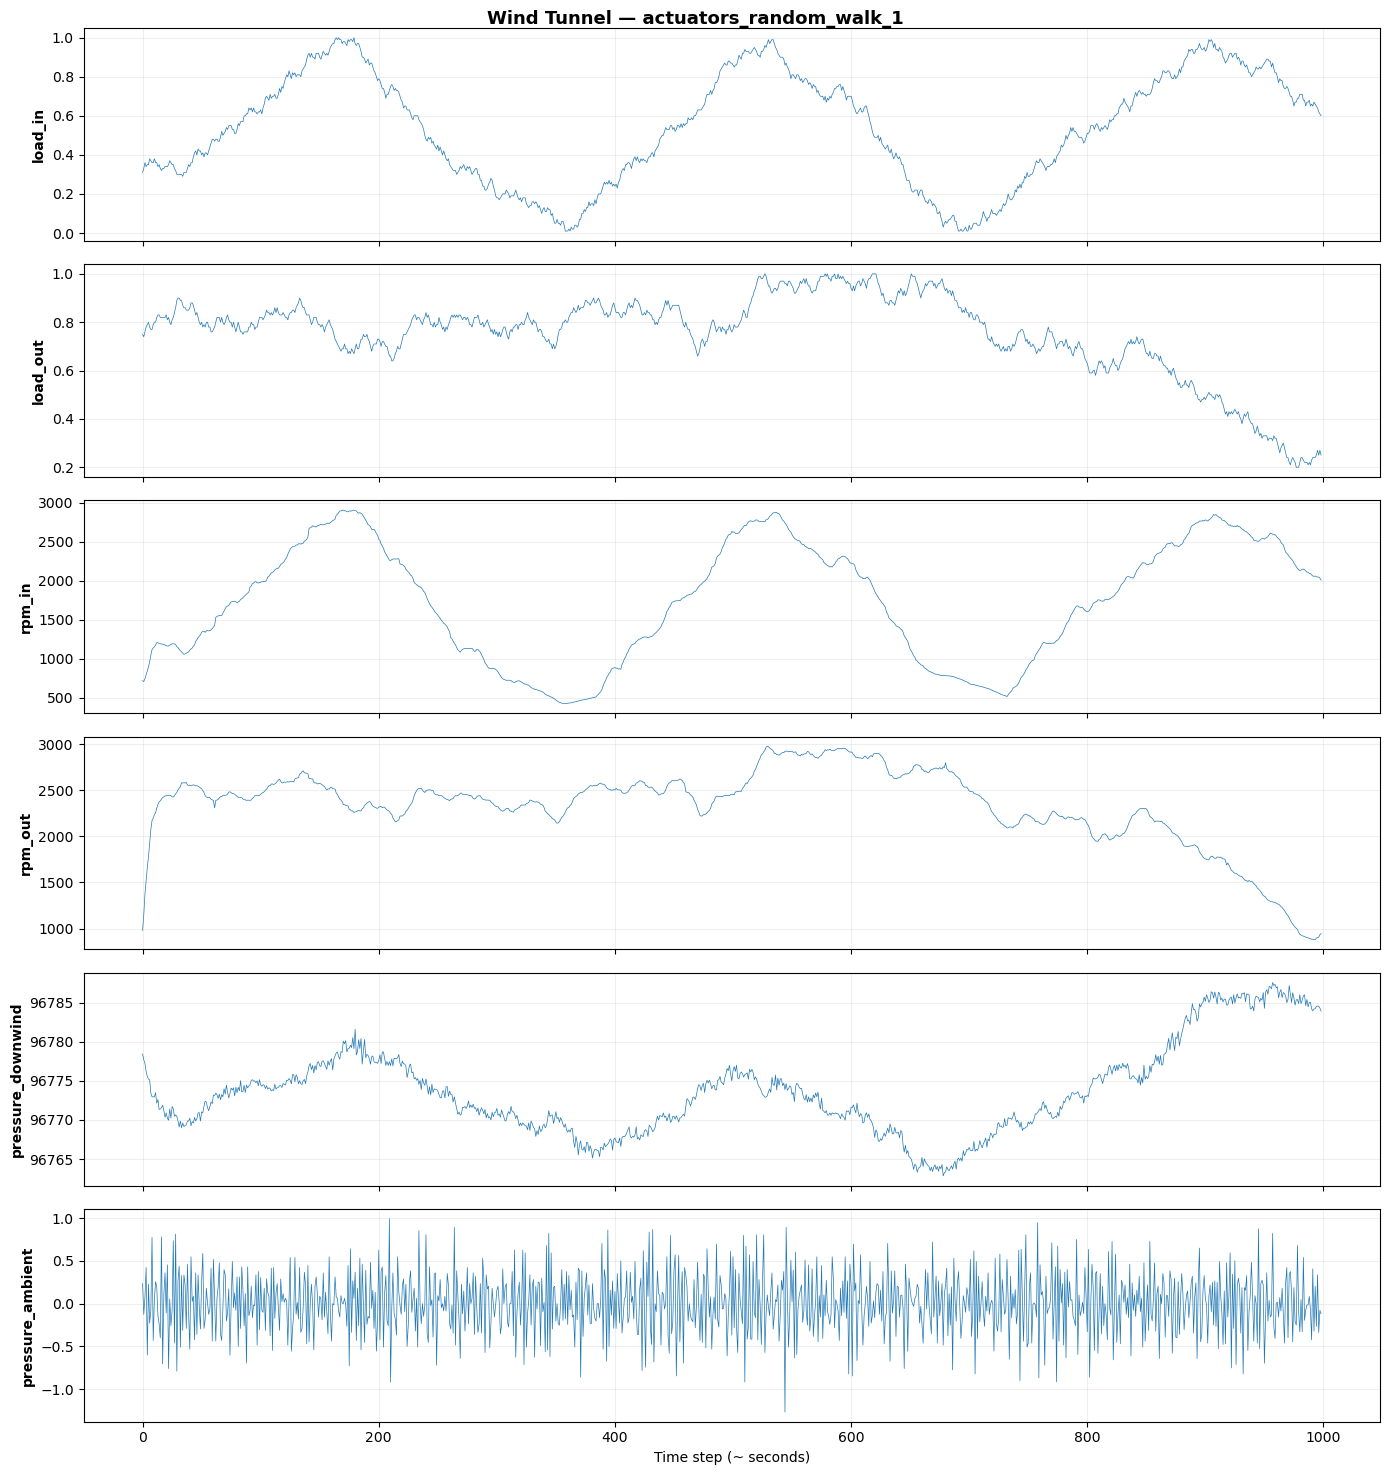

In [22]:
# Plot time series
fig, axes = plt.subplots(len(available_vars), 1, figsize=(14, 2.5*len(available_vars)), sharex=True)
for i, var in enumerate(available_vars):
    axes[i].plot(df_sub[var].values, linewidth=0.5)
    axes[i].set_ylabel(var, fontsize=10, fontweight="bold")
    axes[i].grid(True, alpha=0.2)
axes[-1].set_xlabel("Time step (~ seconds)")
fig.suptitle(f"Wind Tunnel — {EXPERIMENT_NAME}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_time_series.png"), dpi=150, bbox_inches="tight")
plt.show()

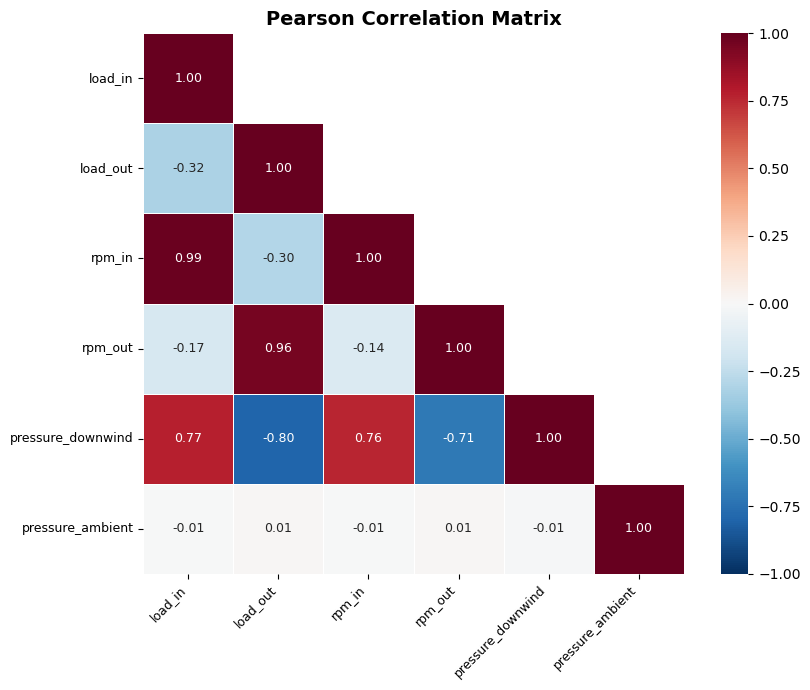


Strong correlations (|r| > 0.5):
                 load_in ↔ rpm_in                 r = +0.987 ← GT edge
                 load_in ↔ pressure_downwind      r = +0.775 ← NO GT edge (spurious?)
                load_out ↔ rpm_out                r = +0.959 ← GT edge
                load_out ↔ pressure_downwind      r = -0.798 ← NO GT edge (spurious?)
                  rpm_in ↔ pressure_downwind      r = +0.759 ← GT edge
                 rpm_out ↔ pressure_downwind      r = -0.715 ← GT edge


In [23]:
# === CORRELATION MATRIX ===
import seaborn as sns

corr_matrix = df_sub.corr(method='pearson')
gt_edges_set = set(tuple(e) for e in GT_EDGES)
fig, ax = plt.subplots(figsize=(9, 7))
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            mask=mask_upper,
            xticklabels=available_vars, yticklabels=available_vars,
            annot_kws={'size': 9}, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
ax.set_xticklabels(available_vars, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(available_vars, rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '00_correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nStrong correlations (|r| > 0.5):')
for i in range(len(available_vars)):
    for j in range(i+1, len(available_vars)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            is_gt = (available_vars[i], available_vars[j]) in gt_edges_set or \
                    (available_vars[j], available_vars[i]) in gt_edges_set
            tag = ' ← GT edge' if is_gt else ' ← NO GT edge (spurious?)'
            print(f'  {available_vars[i]:>22} ↔ {available_vars[j]:<22} r = {r:+.3f}{tag}')

c:\Users\Lenovo Gaming\anaconda3\envs\my_env\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


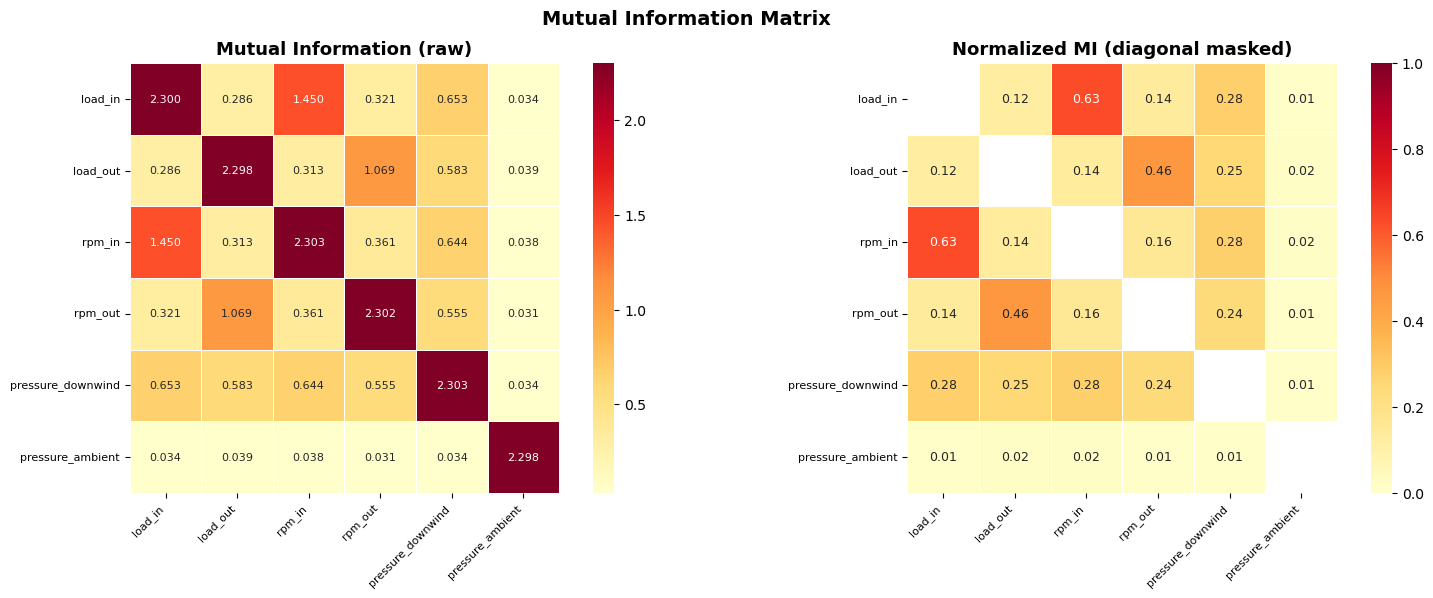


High MI pairs (normalized MI > 0.3):
                 load_in ↔ rpm_in                 MI = 0.630 ← GT edge
                load_out ↔ rpm_out                MI = 0.464 ← GT edge


In [24]:
# === MUTUAL INFORMATION MATRIX ===
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer

gt_edges_set = set(tuple(e) for e in GT_EDGES)

# Discretize for MI estimation (10 equal-frequency bins)
n_bins = 10
disc = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
data_disc = disc.fit_transform(df_sub.values).astype(int)

n_v = len(available_vars)
mi_matrix = np.zeros((n_v, n_v))

for i in range(n_v):
    for j in range(n_v):
        mi_matrix[i, j] = mutual_info_score(data_disc[:, i], data_disc[:, j])

# Normalize to [0, 1]
mi_max = mi_matrix.max()
mi_norm = mi_matrix / mi_max if mi_max > 0 else mi_matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(mi_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=available_vars, yticklabels=available_vars,
            square=True, annot_kws={'size': 8}, linewidths=0.5, ax=axes[0])
axes[0].set_title('Mutual Information (raw)', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(available_vars, rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(available_vars, rotation=0, fontsize=8)

mi_display = mi_norm.copy()
mi_display[np.eye(n_v, dtype=bool)] = np.nan
sns.heatmap(mi_display, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=available_vars, yticklabels=available_vars,
            square=True, annot_kws={'size': 9}, linewidths=0.5, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Normalized MI (diagonal masked)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(available_vars, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(available_vars, rotation=0, fontsize=8)

plt.suptitle('Mutual Information Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '00_mutual_information.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nHigh MI pairs (normalized MI > 0.3):')
for i in range(n_v):
    for j in range(i+1, n_v):
        mi_val = mi_norm[i, j]
        if mi_val > 0.3:
            is_gt = (available_vars[i], available_vars[j]) in gt_edges_set or \
                    (available_vars[j], available_vars[i]) in gt_edges_set
            tag = ' ← GT edge' if is_gt else ''
            print(f'  {available_vars[i]:>22} ↔ {available_vars[j]:<22} MI = {mi_val:.3f}{tag}')

  SHAPIRO-WILK NORMALITY TEST
  H0: the variable follows a normal distribution
  Reject H0 if p < 0.05 → variable is NOT Gaussian

         Variable  W-statistic      p-value Normal?
          load_in     0.953123 2.558035e-17    ✗ No
         load_out     0.882774 8.375939e-27    ✗ No
           rpm_in     0.936210 2.929940e-20    ✗ No
          rpm_out     0.883690 1.031829e-26    ✗ No
pressure_downwind     0.948243 3.087806e-18    ✗ No
 pressure_ambient     0.998229 3.929305e-01   ✓ Yes

Summary: 1/6 Gaussian, 5/6 non-Gaussian.
→ Non-Gaussian variables may reduce ParCorr reliability.
  Consider using GPDC or CMIknn for nonlinear dependencies.


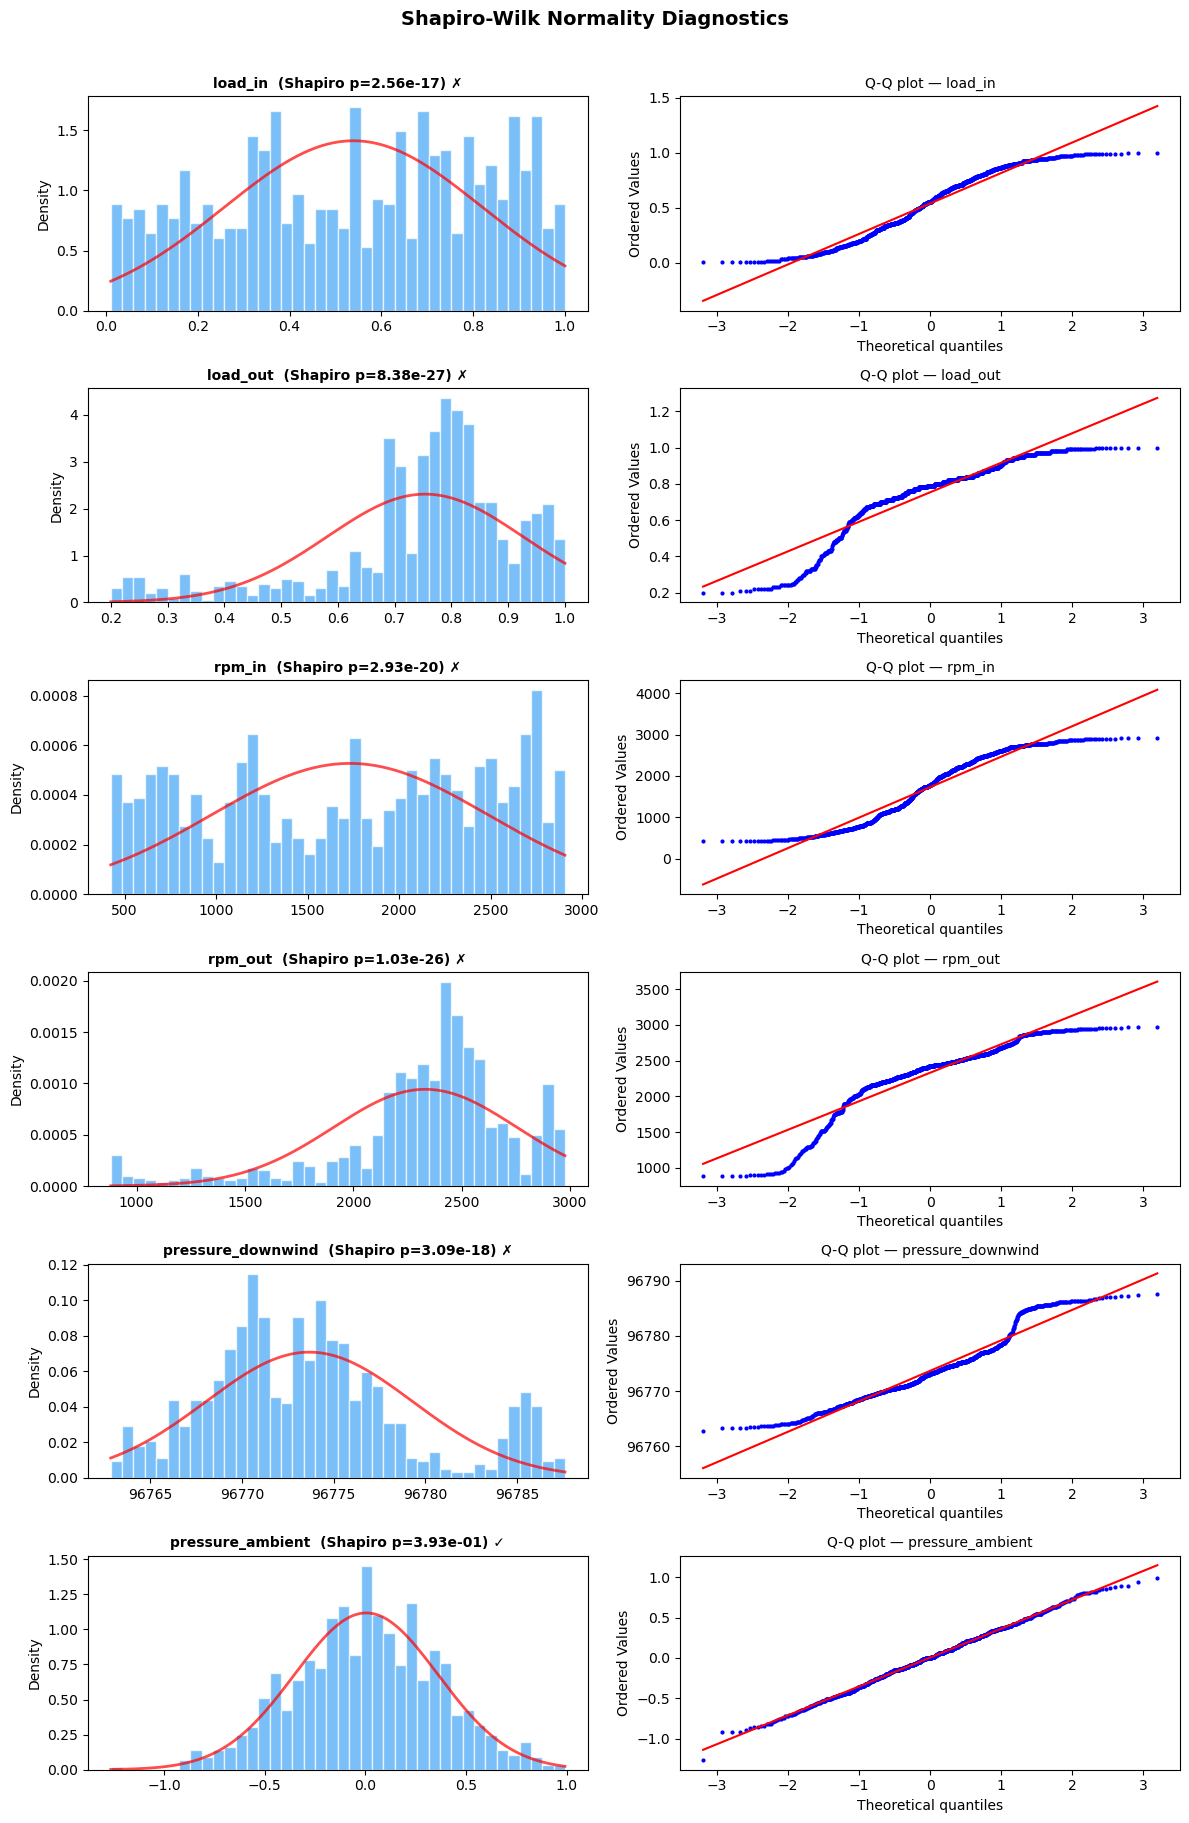

In [25]:
# === SHAPIRO-WILK NORMALITY TEST ===
from scipy import stats

print('=' * 70)
print('  SHAPIRO-WILK NORMALITY TEST')
print('  H0: the variable follows a normal distribution')
print('  Reject H0 if p < 0.05 → variable is NOT Gaussian')
print('=' * 70)

n_shapiro = min(len(df_sub), 5000)
shapiro_results = []

for var in available_vars:
    x = df_sub[var].values[:n_shapiro]
    stat, pval = stats.shapiro(x)
    is_normal = pval >= 0.05
    shapiro_results.append({
        'Variable': var,
        'W-statistic': stat,
        'p-value': pval,
        'Normal?': '✓ Yes' if is_normal else '✗ No'
    })

df_shapiro = pd.DataFrame(shapiro_results)
print(f'\n{df_shapiro.to_string(index=False)}\n')

n_normal = sum(1 for r in shapiro_results if 'Yes' in r['Normal?'])
n_non_normal = len(shapiro_results) - n_normal

print(f'Summary: {n_normal}/{len(available_vars)} Gaussian, '
      f'{n_non_normal}/{len(available_vars)} non-Gaussian.')
if n_non_normal > 0:
    print('→ Non-Gaussian variables may reduce ParCorr reliability.')
    print('  Consider using GPDC or CMIknn for nonlinear dependencies.')

# Histograms + Q-Q plots
fig, axes = plt.subplots(len(available_vars), 2, figsize=(12, 3 * len(available_vars)))

for i, var in enumerate(available_vars):
    x = df_sub[var].values
    p_sw = shapiro_results[i]['p-value']
    
    # Histogram
    axes[i, 0].hist(x, bins=40, density=True, alpha=0.7, color='#42A5F5', edgecolor='white')
    xx = np.linspace(x.min(), x.max(), 200)
    axes[i, 0].plot(xx, stats.norm.pdf(xx, x.mean(), x.std()), 'r-', lw=2, alpha=0.7)
    tag = '✓' if p_sw >= 0.05 else '✗'
    axes[i, 0].set_title(f'{var}  (Shapiro p={p_sw:.2e}) {tag}', fontsize=10, fontweight='bold')
    axes[i, 0].set_ylabel('Density')
    
    # Q-Q plot
    stats.probplot(x, dist='norm', plot=axes[i, 1])
    axes[i, 1].set_title(f'Q-Q plot — {var}', fontsize=10)
    axes[i, 1].get_lines()[0].set_markersize(2)

plt.suptitle('Shapiro-Wilk Normality Diagnostics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '00_shapiro_wilk.png'), dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# === AUGMENTED DICKEY-FULLER STATIONARITY TEST ===
from statsmodels.tsa.stattools import adfuller

print('=' * 70)
print('  AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST')
print('  H0: the series has a unit root (non-stationary)')
print('  Reject H0 if p < 0.05 → series IS stationary')
print('=' * 70)

adf_results = []

for var in available_vars:
    x = df_sub[var].dropna().values
    stat, pval, usedlag, nobs, crit, icbest = adfuller(x, autolag='AIC')
    is_stationary = pval < 0.05
    adf_results.append({
        'Variable': var,
        'ADF statistic': stat,
        'p-value': pval,
        'Lags used': usedlag,
        'Stationary?': '✓ Yes' if is_stationary else '✗ No'
    })

df_adf = pd.DataFrame(adf_results)
print(f'\n{df_adf.to_string(index=False)}\n')

n_stationary = sum(1 for r in adf_results if 'Yes' in r['Stationary?'])
n_non_stationary = len(adf_results) - n_stationary

print(f'Summary: {n_stationary}/{len(available_vars)} stationary, '
      f'{n_non_stationary}/{len(available_vars)} non-stationary.')
if n_non_stationary > 0:
    non_stat_vars = [r['Variable'] for r in adf_results if 'No' in r['Stationary?']]
    print(f'→ Non-stationary variables: {non_stat_vars}')
    print('  These need differencing or detrending before running PCMCI+.')

  AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST
  H0: the series has a unit root (non-stationary)
  Reject H0 if p < 0.05 → series IS stationary

         Variable  ADF statistic      p-value  Lags used Stationary?
          load_in      -2.575056 9.826311e-02         21        ✗ No
         load_out      -0.093197 9.501119e-01          2        ✗ No
           rpm_in      -2.943008 4.057049e-02         20       ✓ Yes
          rpm_out      -0.410411 9.083459e-01          3        ✗ No
pressure_downwind      -0.425947 9.056755e-01          2        ✗ No
 pressure_ambient     -13.775992 9.488243e-26         12       ✓ Yes

Summary: 2/6 stationary, 4/6 non-stationary.
→ Non-stationary variables: ['load_in', 'load_out', 'rpm_out', 'pressure_downwind']
  These need differencing or detrending before running PCMCI+.


In [29]:
T = 1000  # number of time steps to use
df_sub = df_full[available_vars].iloc[:T].reset_index(drop=True)

# Make non-stationary variables stationary by first-order differencing
non_stationary_vars = ["load_in", "load_out", "rpm_out", "pressure_downwind","pressure_ambient"]
for var in non_stationary_vars:
    df_sub[var] = df_sub[var].diff()

df_sub = df_sub.iloc[1:].reset_index(drop=True)  # drop first NaN row

print(f"Data after differencing {non_stationary_vars}: {df_sub.shape}")
df_sub.describe()

Data after differencing ['load_in', 'load_out', 'rpm_out', 'pressure_downwind', 'pressure_ambient']: (999, 6)


,load_in,load_out,rpm_in,rpm_out,pressure_downwind,pressure_ambient
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,0.000290,-0.000511,1730.701307,0.097888,0.004739,0.004411
std,0.016203,0.014179,756.922618,21.299523,0.711520,0.357188
min,-0.030000,-0.030000,423.824585,-81.755859,-3.296875,-1.265625
25%,-0.010000,-0.010000,1092.498718,-9.823792,-0.472656,-0.234375
50%,0.000000,0.000000,1778.937378,-1.593750,0.000000,0.000000
75%,0.010000,0.010000,2425.614502,7.953857,0.468750,0.246094
max,0.030000,0.030000,2906.976807,230.333618,2.484375,0.992188


In [30]:
# === AUGMENTED DICKEY-FULLER STATIONARITY TEST ===
from statsmodels.tsa.stattools import adfuller

print('=' * 70)
print('  AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST')
print('  H0: the series has a unit root (non-stationary)')
print('  Reject H0 if p < 0.05 → series IS stationary')
print('=' * 70)

adf_results = []

for var in available_vars:
    x = df_sub[var].dropna().values
    stat, pval, usedlag, nobs, crit, icbest = adfuller(x, autolag='AIC')
    is_stationary = pval < 0.05
    adf_results.append({
        'Variable': var,
        'ADF statistic': stat,
        'p-value': pval,
        'Lags used': usedlag,
        'Stationary?': '✓ Yes' if is_stationary else '✗ No'
    })

df_adf = pd.DataFrame(adf_results)
print(f'\n{df_adf.to_string(index=False)}\n')

n_stationary = sum(1 for r in adf_results if 'Yes' in r['Stationary?'])
n_non_stationary = len(adf_results) - n_stationary

print(f'Summary: {n_stationary}/{len(available_vars)} stationary, '
      f'{n_non_stationary}/{len(available_vars)} non-stationary.')
if n_non_stationary > 0:
    non_stat_vars = [r['Variable'] for r in adf_results if 'No' in r['Stationary?']]
    print(f'→ Non-stationary variables: {non_stat_vars}')
    print('  These need differencing or detrending before running PCMCI+.')

  AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST
  H0: the series has a unit root (non-stationary)
  Reject H0 if p < 0.05 → series IS stationary

         Variable  ADF statistic      p-value  Lags used Stationary?
          load_in      -3.722162 3.812009e-03         20       ✓ Yes
         load_out     -19.671762 0.000000e+00          1       ✓ Yes
           rpm_in      -2.943008 4.057049e-02         20       ✓ Yes
          rpm_out     -11.868505 6.588024e-22          2       ✓ Yes
pressure_downwind     -31.113055 0.000000e+00          1       ✓ Yes
 pressure_ambient     -13.775992 9.488243e-26         12       ✓ Yes

Summary: 6/6 stationary, 0/6 non-stationary.


In [31]:
# Verify stationarity after differencing
print('\n--- ADF test AFTER differencing ---')
for var in available_vars:
    x = df_sub[var].dropna().values
    stat, pval, *_ = adfuller(x, autolag='AIC')
    tag = '✓' if pval < 0.05 else '✗'
    print(f'  {var:>20s}  p={pval:.4e}  {tag}')


--- ADF test AFTER differencing ---
               load_in  p=3.8120e-03  ✓
              load_out  p=0.0000e+00  ✓
                rpm_in  p=4.0570e-02  ✓
               rpm_out  p=6.5880e-22  ✓
     pressure_downwind  p=0.0000e+00  ✓
      pressure_ambient  p=9.4882e-26  ✓


---
## 2. Run PCMCI+ with Multiple CI Tests

We compare three conditional independence tests:
- **RobustParCorr**: robust partial correlation (handles non-Gaussian residuals)
- **GPDC**: Gaussian Process regression + Distance Correlation (nonlinear)
- **CMIknn**: Conditional Mutual Information via k-NN (fully nonparametric, slowest)


In [32]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "coverage", "dcor"])

0

In [33]:
import time
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
import tigramite.plotting as tp
from tigramite.independence_tests.robust_parcorr import RobustParCorr

# Try importing optional CI tests
try:
    from tigramite.independence_tests.gpdc import GPDC
    HAS_GPDC = True
    print("GPDC available")
except ImportError:
    HAS_GPDC = False
    print("GPDC NOT available — install scikit-learn and dcor")

try:
    from tigramite.independence_tests.cmiknn import CMIknn
    HAS_CMIKNN = True
    print("CMIknn available")
except ImportError:
    HAS_CMIKNN = False
    print("CMIknn NOT available — install numba")

GPDC available
CMIknn available


In [34]:
# Define CI tests to run
ci_tests = {}
ci_tests["RobustParCorr"] = RobustParCorr(significance='analytic')

if HAS_GPDC:
    ci_tests["GPDC"] = GPDC(significance='analytic', gp_params=None)

if HAS_CMIKNN:
    ci_tests["CMIknn"] = CMIknn(knn=0.1, shuffle_neighbors=5,
                                 significance='shuffle_test', sig_samples=200)

print(f"CI tests to run: {list(ci_tests.keys())}")

CI tests to run: ['RobustParCorr', 'GPDC', 'CMIknn']


In [35]:
# Helper functions
def extract_lagged_pvalues(p_matrix, d, tau_max):
    """Get p-values for all candidate lagged edges (no self-loops)."""
    edges, pvals = [], []
    for i in range(d):
        for j in range(d):
            if i == j: continue
            for tau in range(1, tau_max+1):
                edges.append((i, j, tau))
                pvals.append(p_matrix[i, j, tau])
    return edges, np.array(pvals)


def extract_discovered_edges(graph_array, p_matrix, val_matrix, var_names, tau_max):
    """Get list of significant edges."""
    d = len(var_names)
    edges = []
    for i in range(d):
        for j in range(d):
            for tau in range(1, tau_max+1):
                if graph_array[i, j, tau] == '-->':
                    edges.append({'source': var_names[i], 'target': var_names[j],
                                  'lag': tau, 'p_value': float(p_matrix[i,j,tau]),
                                  'test_stat': float(val_matrix[i,j,tau]),
                                  'kind': 'lagged'})
    for i in range(d):
        for j in range(i+1, d):
            if graph_array[i, j, 0] in ['-->', 'o-o', '<->', 'x-x']:
                edges.append({'source': var_names[i], 'target': var_names[j],
                              'lag': 0, 'p_value': float(p_matrix[i,j,0]),
                              'test_stat': float(val_matrix[i,j,0]),
                              'edge_type': graph_array[i,j,0], 'kind': 'contemp'})
    return edges

### 2.1 Run PCMCI+ with RobustParCorr


Running PCMCI+ with T=1000, d=6, tau_max=5, pc_alpha=0.2 ...

##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = robust_par_corr
tau_min = 1
tau_max = 5
pc_alpha = [0.2]
max_conds_dim = None
max_combinations = 1



## Variable load_in

Iterating through pc_alpha = [0.2]:

# pc_alpha = 0.2 (1/1):

Testing condition sets of dimension 0:

    Link (load_in -1) -?> load_in (1/30):
    Subset 0: () gives pval = 0.28024 / val = -0.034
    Non-significance detected.

    Link (load_in -2) -?> load_in (2/30):
    Subset 0: () gives pval = 0.00000 / val =  0.181
    No conditions of dimension 0 left.

    Link (load_in -3) -?> load_in (3/30):
    Subset 0: () gives pval = 0.58227 / val =  0.018
    Non-significance detected.

    Link (load_in -4) -?> load_in (4/30):
    Subset 0: () gives pval = 0.00000 / val =  0.222
    No conditions of dimension 0 left.

    Link (load_in -5) -?> load_in (5/30):
    Subset 0: () gives pval = 0.00838 / val = -0.08

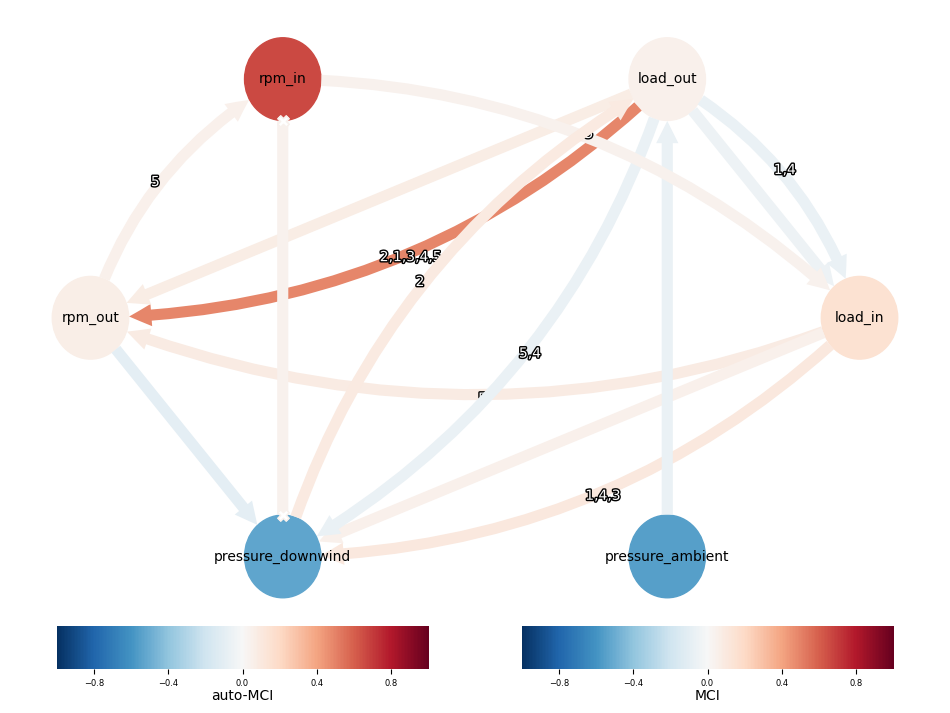


Mean p-value: 0.5179
Candidate edges: 150


In [36]:
import time
import numpy as np
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.robust_parcorr import RobustParCorr
import tigramite.plotting as tp
import matplotlib.pyplot as plt

# Prepare data
data_array = df_sub.values.astype(np.float64)
dataframe = pp.DataFrame(data_array, var_names=available_vars)

# ParCorr
parcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=2)

print(f"Running PCMCI+ with T={T}, d={len(available_vars)}, tau_max=5, pc_alpha=0.2 ...")
t0 = time.time()

results = pcmci.run_pcmciplus(
    tau_min=0,
    tau_max=5,
    pc_alpha=0.2,
)

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s")

# Print all discovered edges
graph = results['graph']
p_matrix = results['p_matrix']
val_matrix = results['val_matrix']

print("\n=== Discovered edges ===")
for i in range(len(available_vars)):
    for j in range(len(available_vars)):
        for tau in range(0, 6):
            if graph[i, j, tau] in ['-->', 'o-o', '<->']:
                if tau > 0:
                    print(f"  {available_vars[i]}(t-{tau}) --> {available_vars[j]}(t)  "
                          f"p={p_matrix[i,j,tau]:.6f}")
                else:
                    print(f"  {available_vars[i]}(t) {graph[i,j,0]} {available_vars[j]}(t)  "
                          f"p={p_matrix[i,j,0]:.6f}")

# Plot
tp.plot_graph(val_matrix=val_matrix, graph=graph, 
              var_names=available_vars, figsize=(12, 8))
plt.show()

# Store for later use
all_results = {}
edge_indices, pvalues = [], []
d = len(available_vars)
for i in range(d):
    for j in range(d):
        if i == j: continue
        for tau in range(1, 6):
            edge_indices.append((i, j, tau))
            pvalues.append(p_matrix[i, j, tau])
pvalues = np.array(pvalues)

all_results["RobustParCorr"] = {
    'val_matrix': val_matrix, 'p_matrix': p_matrix,
    'graph': graph, 'pvalues': pvalues,
    'edge_indices': edge_indices, 'elapsed': elapsed,
}
print(f"\nMean p-value: {pvalues.mean():.4f}")
print(f"Candidate edges: {len(pvalues)}")

In [37]:
# === FULL METRICS + CRI + PLOTS ===
import seaborn as sns

d = len(available_vars)
TAU_MAX = 5
gt_edges_set = set(tuple(e) for e in GT_EDGES)

# ── 1. CRI_TS ──
cri_ts = 1.0 - pvalues.mean()
print(f"CRI_TS = {cri_ts:.4f}  (>0.5 = causal signal detected)")
print(f"Candidate edges: {len(pvalues)} (expected {d*(d-1)*TAU_MAX})")

# ── 2. Summary adjacency (collapse lags) ──
learned_adj = np.zeros((d, d), dtype=int)
for i in range(d):
    for j in range(d):
        for tau in range(1, TAU_MAX+1):
            if graph[i, j, tau] == '-->':
                learned_adj[i, j] = 1

# ── 3. Compute all metrics ──
mask = ~np.eye(d, dtype=bool)
g_flat = gt_adj[mask].flatten()
l_flat = learned_adj[mask].flatten()

TP = int(((g_flat==1)&(l_flat==1)).sum())
FP = int(((g_flat==0)&(l_flat==1)).sum())
FN = int(((g_flat==1)&(l_flat==0)).sum())
TN = int(((g_flat==0)&(l_flat==0)).sum())

precision = TP/(TP+FP) if (TP+FP) > 0 else 0.0
recall    = TP/(TP+FN) if (TP+FN) > 0 else 0.0
f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
fpr       = FP/(FP+TN) if (FP+TN) > 0 else 0.0
shd       = FP + FN

# ── 4. P-value split: true vs absent edges ──
p_true_list, p_absent_list = [], []
for idx_tuple, pval in zip(edge_indices, pvalues):
    i, j, tau = idx_tuple
    src, tgt = available_vars[i], available_vars[j]
    if (src, tgt) in gt_edges_set:
        p_true_list.append(pval)
    else:
        p_absent_list.append(pval)
p_true = np.array(p_true_list)
p_absent = np.array(p_absent_list)

# ── 5. METRICS TABLE ──
metrics_dict = {
    "CRI_TS": cri_ts,
    "Precision": precision,
    "Recall (TPR)": recall,
    "F1 Score": f1,
    "FPR": fpr,
    "SHD": shd,
    "TP": TP, "FP": FP, "FN": FN, "TN": TN,
    "Edges discovered": int(learned_adj.sum()),
    "True edges": int(gt_adj.sum()),
    "Mean p (all)": pvalues.mean(),
    "Mean p (true edges)": p_true.mean() if len(p_true) > 0 else None,
    "Mean p (absent edges)": p_absent.mean() if len(p_absent) > 0 else None,
}

print("\n" + "="*55)
print("  METRICS TABLE — RobustParCorr")
print("="*55)
for k, v in metrics_dict.items():
    if isinstance(v, float):
        print(f"  {k:<25s}  {v:.4f}")
    else:
        print(f"  {k:<25s}  {v}")
print("="*55)

# Save as CSV too
metrics_df = pd.DataFrame([metrics_dict])

CRI_TS = 0.4821  (>0.5 = causal signal detected)
Candidate edges: 150 (expected 150)

  METRICS TABLE — RobustParCorr
  CRI_TS                     0.4821
  Precision                  0.1250
  Recall (TPR)               0.2000
  F1 Score                   0.1538
  FPR                        0.2800
  SHD                        11
  TP                         1
  FP                         7
  FN                         4
  TN                         18
  Edges discovered           14
  True edges                 5
  Mean p (all)               0.5179
  Mean p (true edges)        0.4361
  Mean p (absent edges)      0.5342


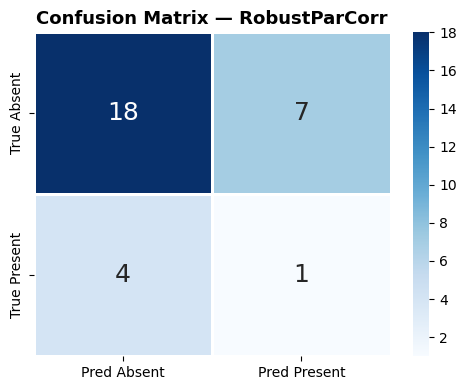

In [38]:
# === PLOT 1: Confusion Matrix ===
cm = np.array([[TN, FP], [FN, TP]])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Absent', 'Pred Present'],
            yticklabels=['True Absent', 'True Present'],
            annot_kws={'size': 18}, ax=ax, linewidths=1, linecolor='white')
ax.set_title('Confusion Matrix — RobustParCorr', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_confusion_RobustParCorr.png"), dpi=150)
plt.show()

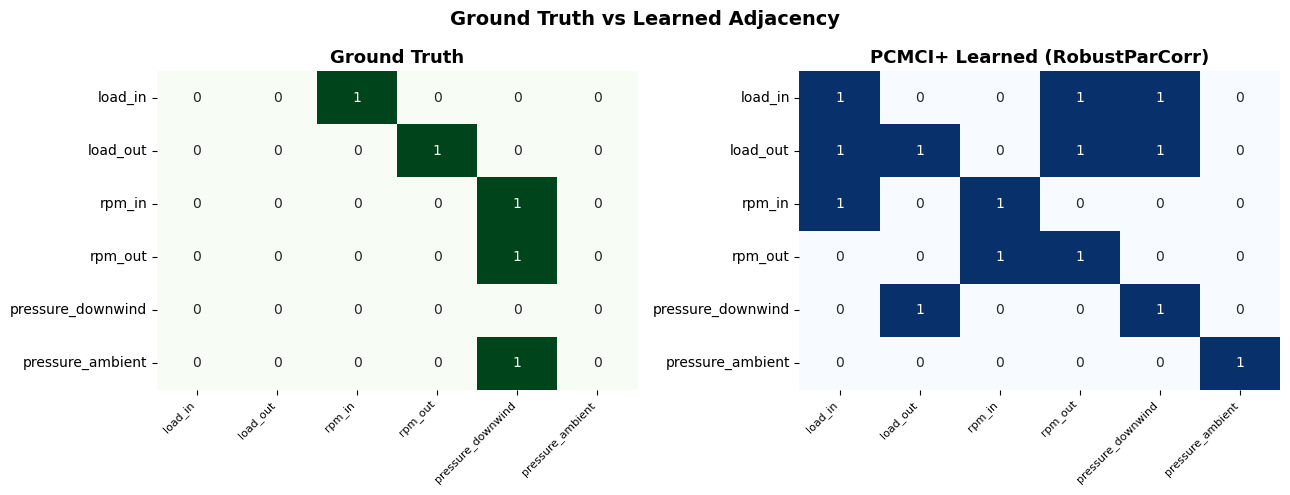

In [39]:
# === PLOT 2: Ground Truth vs Learned adjacency ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(gt_adj, annot=True, fmt='d', cmap='Greens', vmin=0, vmax=1, cbar=False,
            xticklabels=available_vars, yticklabels=available_vars, ax=axes[0])
axes[0].set_title('Ground Truth', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(available_vars, rotation=45, ha='right', fontsize=8)

sns.heatmap(learned_adj, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=1, cbar=False,
            xticklabels=available_vars, yticklabels=available_vars, ax=axes[1])
axes[1].set_title('PCMCI+ Learned (RobustParCorr)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(available_vars, rotation=45, ha='right', fontsize=8)

plt.suptitle('Ground Truth vs Learned Adjacency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_adj_comparison_RobustParCorr.png"), dpi=150)
plt.show()

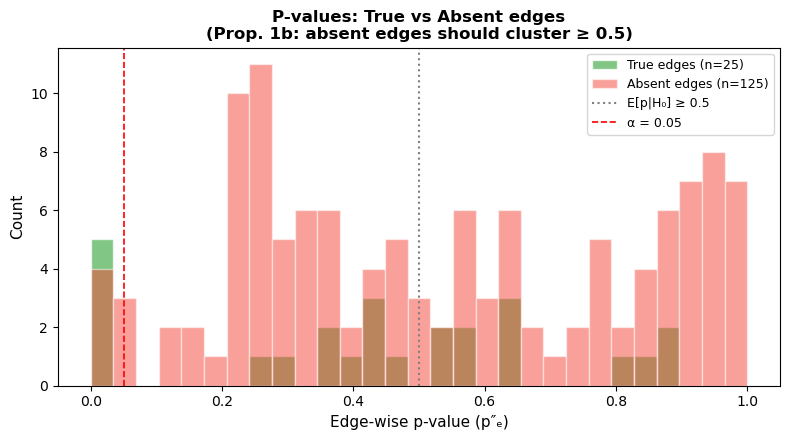

Mean p-value (true edges):   0.4361
Mean p-value (absent edges): 0.5342


In [40]:
# === PLOT 3: P-values true vs absent edges (validates Proposition 1b) ===
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 1, 30)
ax.hist(p_true, bins=bins, alpha=0.7, color='#4CAF50',
        label=f'True edges (n={len(p_true)})', edgecolor='white')
ax.hist(p_absent, bins=bins, alpha=0.5, color='#F44336',
        label=f'Absent edges (n={len(p_absent)})', edgecolor='white')
ax.axvline(0.5, color='gray', ls=':', lw=1.5, label='E[p|H₀] ≥ 0.5')
ax.axvline(0.05, color='red', ls='--', lw=1.2, label='α = 0.05')
ax.set_xlabel("Edge-wise p-value (p″ₑ)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("P-values: True vs Absent edges\n(Prop. 1b: absent edges should cluster ≥ 0.5)",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_pval_true_vs_absent_RobustParCorr.png"), dpi=150)
plt.show()

print(f"Mean p-value (true edges):   {p_true.mean():.4f}")
print(f"Mean p-value (absent edges): {p_absent.mean():.4f}")

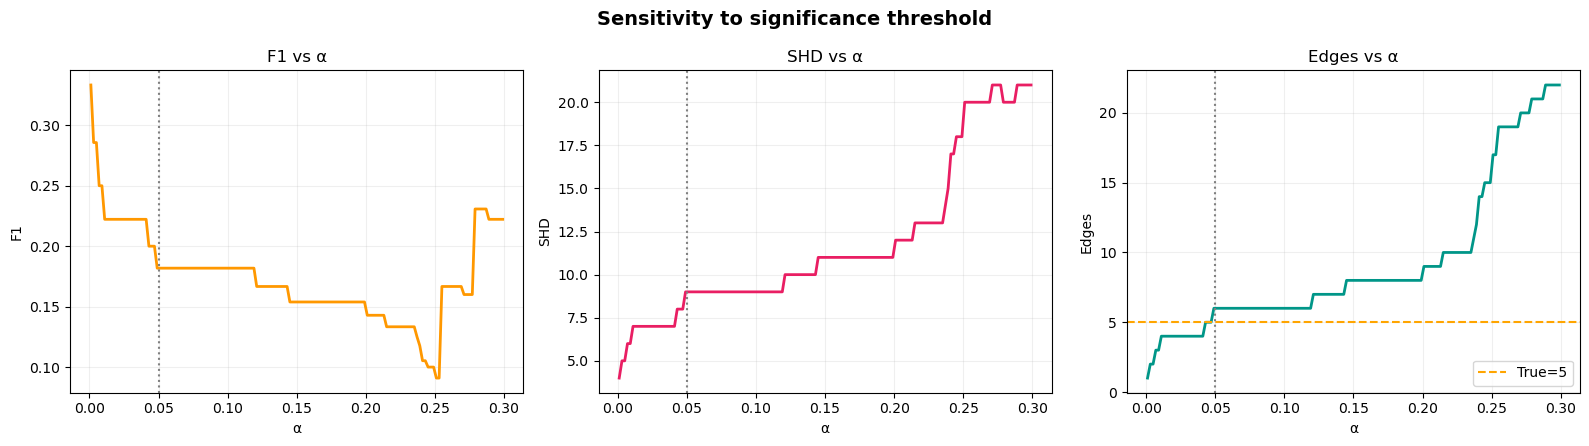

In [41]:
# === PLOT 5: Sensitivity to alpha threshold ===
alphas = np.arange(0.001, 0.30, 0.002)
sens_f1, sens_shd, sens_edges = [], [], []

for alpha in alphas:
    adj_a = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(d):
            if i == j: continue
            for tau in range(1, TAU_MAX+1):
                if p_matrix[i, j, tau] <= alpha:
                    adj_a[i, j] = 1
    g_f = gt_adj[mask].flatten()
    l_f = adj_a[mask].flatten()
    tp_a = ((g_f==1)&(l_f==1)).sum()
    fp_a = ((g_f==0)&(l_f==1)).sum()
    fn_a = ((g_f==1)&(l_f==0)).sum()
    p_a = tp_a/(tp_a+fp_a) if (tp_a+fp_a) > 0 else 0
    r_a = tp_a/(tp_a+fn_a) if (tp_a+fn_a) > 0 else 0
    f1_a = 2*p_a*r_a/(p_a+r_a) if (p_a+r_a) > 0 else 0
    sens_f1.append(f1_a)
    sens_shd.append(fp_a + fn_a)
    sens_edges.append(int(adj_a.sum()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(alphas, sens_f1, lw=2, color='#FF9800')
axes[0].axvline(0.05, color='gray', ls=':'); axes[0].set_title('F1 vs α')
axes[0].set_xlabel('α'); axes[0].set_ylabel('F1'); axes[0].grid(True, alpha=0.2)

axes[1].plot(alphas, sens_shd, lw=2, color='#E91E63')
axes[1].axvline(0.05, color='gray', ls=':'); axes[1].set_title('SHD vs α')
axes[1].set_xlabel('α'); axes[1].set_ylabel('SHD'); axes[1].grid(True, alpha=0.2)

axes[2].plot(alphas, sens_edges, lw=2, color='#009688')
axes[2].axhline(int(gt_adj.sum()), color='orange', ls='--', label=f"True={int(gt_adj.sum())}")
axes[2].axvline(0.05, color='gray', ls=':'); axes[2].set_title('Edges vs α')
axes[2].set_xlabel('α'); axes[2].set_ylabel('Edges'); axes[2].legend(); axes[2].grid(True, alpha=0.2)

plt.suptitle('Sensitivity to significance threshold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_sensitivity_RobustParCorr.png"), dpi=150, bbox_inches='tight')
plt.show()

In [42]:
## CRI vs TPR 

# === CRI_TS vs True Positives across sample sizes ===
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.robust_parcorr import RobustParCorr
import time

TAU_MAX = 5
sample_sizes = [200, 500, 1000, 2000, 5000]
gt_edges_set = set(tuple(e) for e in GT_EDGES)

results_by_T = []

for T in sample_sizes:
    print(f"\n--- T = {T} ---")
    
    # Get data (no downsampling)
    df_sub = df_full[available_vars].iloc[:T].reset_index(drop=True)
    df_sub["pressure_ambient"] = df_sub["pressure_ambient"].diff()
    df_sub = df_sub.iloc[1:].reset_index(drop=True)
    data_array = df_sub.values.astype(np.float64)
    dataframe = pp.DataFrame(data_array, var_names=available_vars)
    
    # Run PCMCI+
    parcorr = RobustParCorr(significance='analytic')
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)
    
    t0 = time.time()
    res = pcmci.run_pcmciplus(tau_min=0, tau_max=TAU_MAX, pc_alpha=0.2)
    elapsed = time.time() - t0
    
    g = res['graph']
    p_mat = res['p_matrix']
    d = len(available_vars)
    
    # Summary adjacency
    learned = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(d):
            for tau in range(1, TAU_MAX+1):
                if g[i, j, tau] == '-->':
                    learned[i, j] = 1
    
    # Metrics
    mask = ~np.eye(d, dtype=bool)
    g_f = gt_adj[mask].flatten()
    l_f = learned[mask].flatten()
    TP = int(((g_f==1)&(l_f==1)).sum())
    FP = int(((g_f==0)&(l_f==1)).sum())
    FN = int(((g_f==1)&(l_f==0)).sum())
    
    prec = TP/(TP+FP) if (TP+FP) > 0 else 0
    rec  = TP/(TP+FN) if (TP+FN) > 0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    
    # CRI_TS
    pvalues = []
    for i in range(d):
        for j in range(d):
            if i == j: continue
            for tau in range(1, TAU_MAX+1):
                pvalues.append(p_mat[i, j, tau])
    pvalues = np.array(pvalues)
    cri = 1.0 - pvalues.mean()
    
    results_by_T.append({
        'T': T, 'CRI_TS': cri, 'TP': TP, 'FP': FP, 'FN': FN,
        'precision': prec, 'recall': rec, 'F1': f1,
        'SHD': FP+FN, 'time': elapsed,
    })
    
    print(f"  CRI={cri:.4f}  TP={TP}  FP={FP}  FN={FN}  F1={f1:.3f}  ({elapsed:.1f}s)")

results_T_df = pd.DataFrame(results_by_T)
results_T_df


--- T = 200 ---
  CRI=0.4260  TP=4  FP=4  FN=1  F1=0.615  (1.3s)

--- T = 500 ---
  CRI=0.3613  TP=2  FP=3  FN=3  F1=0.400  (3.2s)

--- T = 1000 ---
  CRI=0.3622  TP=2  FP=0  FN=3  F1=0.571  (2.6s)

--- T = 2000 ---
  CRI=0.3412  TP=2  FP=0  FN=3  F1=0.571  (2.6s)

--- T = 5000 ---
  CRI=0.3412  TP=2  FP=0  FN=3  F1=0.571  (2.6s)


,T,CRI_TS,TP,FP,FN,precision,recall,F1,SHD,time
0,200,0.426033,4,4,1,0.5,0.8,0.615385,5,1.251167
1,500,0.361270,2,3,3,0.4,0.4,0.400000,6,3.172526
2,1000,0.362224,2,0,3,1.0,0.4,0.571429,3,2.565617
3,2000,0.341186,2,0,3,1.0,0.4,0.571429,3,2.629709
4,5000,0.341186,2,0,3,1.0,0.4,0.571429,3,2.550808


In [43]:
# === CRI interpretation ===
n_true_edges = int(gt_adj.sum())
n_candidate = len(pvalues)  # d*(d-1)*tau_max

# Theoretical bounds
cri_null = 0.5  # expected under global null (no causal structure)

# Theoretical max: true edges contribute p=0, absent contribute p=0.5
# But true edges appear at specific lags, not all lags
# Count how many candidate edges correspond to true causal pairs
n_true_pairs = n_true_edges  # number of directed pairs i->j that are true
# Each true pair has tau_max candidate edges (one per lag)
# At least one lag should have small p, others might not
# Conservative: assume only 1 lag per true pair has p≈0
cri_max_conservative = 1.0 - ((n_candidate - n_true_pairs) * 0.5) / n_candidate
# Optimistic: assume all lags for true pairs have p≈0
cri_max_optimistic = 1.0 - ((n_candidate - n_true_pairs * TAU_MAX) * 0.5) / n_candidate

print("=" * 55)
print("  CRI_TS INTERPRETATION GUIDE")
print("=" * 55)
print(f"  Variables:        {len(available_vars)}")
print(f"  tau_max:          {TAU_MAX}")
print(f"  Candidate edges:  {n_candidate}")
print(f"  True edges:       {n_true_edges}")
print(f"  Sparsity:         {n_true_edges/n_candidate:.1%}")
print()
print(f"  CRI_TS benchmarks:")
print(f"    Global null (no structure):     {cri_null:.3f}")
print(f"    Theoretical max (conservative): {cri_max_conservative:.3f}")
print(f"    Theoretical max (optimistic):   {cri_max_optimistic:.3f}")
print(f"    Our result:                     {1.0 - pvalues.mean():.3f}")
print()

# Where does our CRI fall as a percentage between null and max?
our_cri = 1.0 - pvalues.mean()
pct = (our_cri - cri_null) / (cri_max_conservative - cri_null) * 100
print(f"  Our CRI is {pct:.0f}% of the way from null to theoretical max")
print()
print("  Key insight: CRI_TS absolute value depends on graph sparsity.")
print("  A sparse graph (few true edges) will never reach 1.0.")
print("  Use CRI to COMPARE methods, not as a standalone score.")
print("=" * 55)

  CRI_TS INTERPRETATION GUIDE
  Variables:        6
  tau_max:          5
  Candidate edges:  150
  True edges:       5
  Sparsity:         3.3%

  CRI_TS benchmarks:
    Global null (no structure):     0.500
    Theoretical max (conservative): 0.517
    Theoretical max (optimistic):   0.583
    Our result:                     0.341

  Our CRI is -953% of the way from null to theoretical max

  Key insight: CRI_TS absolute value depends on graph sparsity.
  A sparse graph (few true edges) will never reach 1.0.
  Use CRI to COMPARE methods, not as a standalone score.


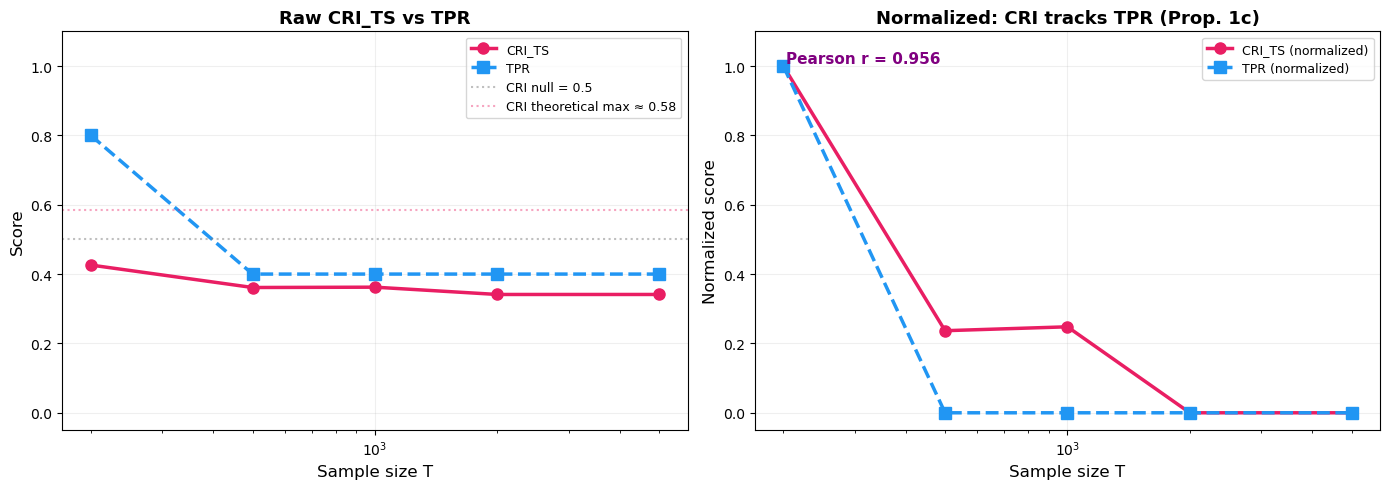


Why CRI_TS doesn't reach 1.0:
  True edges: 5 (× 5 lags = 25 edge-lag pairs)
  Total candidates: 150
  Sparsity: 16.7%
  Even with perfect discovery, CRI_TS ≈ 0.583

Pearson correlation CRI vs TPR: r = 0.956


In [44]:
# === CRI_TS vs TPR — both normalized to show correlation ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Raw values
axes[0].plot(results_T_df['T'], results_T_df['CRI_TS'], 'o-', color='#E91E63',
             lw=2.5, ms=8, label='CRI_TS')
axes[0].plot(results_T_df['T'], results_T_df['recall'], 's--', color='#2196F3',
             lw=2.5, ms=8, label='TPR')
axes[0].axhline(0.5, color='gray', ls=':', alpha=0.5, label='CRI null = 0.5')

# Compute theoretical CRI maximum (if all true edges have p=0, absent edges p=0.5)
n_true = int(gt_adj.sum())
n_candidate = len(pvalues)  # d*(d-1)*tau_max
cri_max = 1.0 - (n_candidate - n_true * TAU_MAX) * 0.5 / n_candidate
axes[0].axhline(cri_max, color='#E91E63', ls=':', alpha=0.4,
                label=f'CRI theoretical max ≈ {cri_max:.2f}')

axes[0].set_xscale('log')
axes[0].set_xlabel('Sample size T', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_ylim(-0.05, 1.1)
axes[0].legend(fontsize=9)
axes[0].set_title('Raw CRI_TS vs TPR', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.2)

# Panel 2: Both min-max normalized to [0,1] to show correlation
from sklearn.preprocessing import minmax_scale

cri_vals = results_T_df['CRI_TS'].values
tpr_vals = results_T_df['recall'].values

# Normalize each to [0,1]
if cri_vals.max() > cri_vals.min():
    cri_norm = (cri_vals - cri_vals.min()) / (cri_vals.max() - cri_vals.min())
else:
    cri_norm = cri_vals
if tpr_vals.max() > tpr_vals.min():
    tpr_norm = (tpr_vals - tpr_vals.min()) / (tpr_vals.max() - tpr_vals.min())
else:
    tpr_norm = tpr_vals

axes[1].plot(results_T_df['T'], cri_norm, 'o-', color='#E91E63',
             lw=2.5, ms=8, label='CRI_TS (normalized)')
axes[1].plot(results_T_df['T'], tpr_norm, 's--', color='#2196F3',
             lw=2.5, ms=8, label='TPR (normalized)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Sample size T', fontsize=12)
axes[1].set_ylabel('Normalized score', fontsize=12)
axes[1].set_ylim(-0.05, 1.1)
axes[1].legend(fontsize=9)
axes[1].set_title('Normalized: CRI tracks TPR (Prop. 1c)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.2)

# Compute correlation
corr = np.corrcoef(cri_vals, tpr_vals)[0, 1]
axes[1].text(0.05, 0.92, f'Pearson r = {corr:.3f}', transform=axes[1].transAxes,
             fontsize=11, fontweight='bold', color='purple')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_cri_vs_tpr.png"), dpi=150)
plt.show()

print(f"\nWhy CRI_TS doesn't reach 1.0:")
print(f"  True edges: {n_true} (× {TAU_MAX} lags = {n_true * TAU_MAX} edge-lag pairs)")
print(f"  Total candidates: {n_candidate}")
print(f"  Sparsity: {n_true * TAU_MAX / n_candidate:.1%}")
print(f"  Even with perfect discovery, CRI_TS ≈ {cri_max:.3f}")
print(f"\nPearson correlation CRI vs TPR: r = {corr:.3f}")

  FULL METRICS TABLE
     T   CRI_TS     TPR     FPR     FNR     TNR     FDR    Prec      F1   TP   FP   FN   TN
------------------------------------------------------------------------------------------
   200   0.4260   0.800   0.160   0.200   0.840   0.500   0.500   0.615    4    4    1   21
   500   0.3613   0.400   0.120   0.600   0.880   0.600   0.400   0.400    2    3    3   22
  1000   0.3622   0.400   0.000   0.600   1.000   0.000   1.000   0.571    2    0    3   25
  2000   0.3412   0.400   0.000   0.600   1.000   0.000   1.000   0.571    2    0    3   25
  5000   0.3412   0.400   0.000   0.600   1.000   0.000   1.000   0.571    2    0    3   25


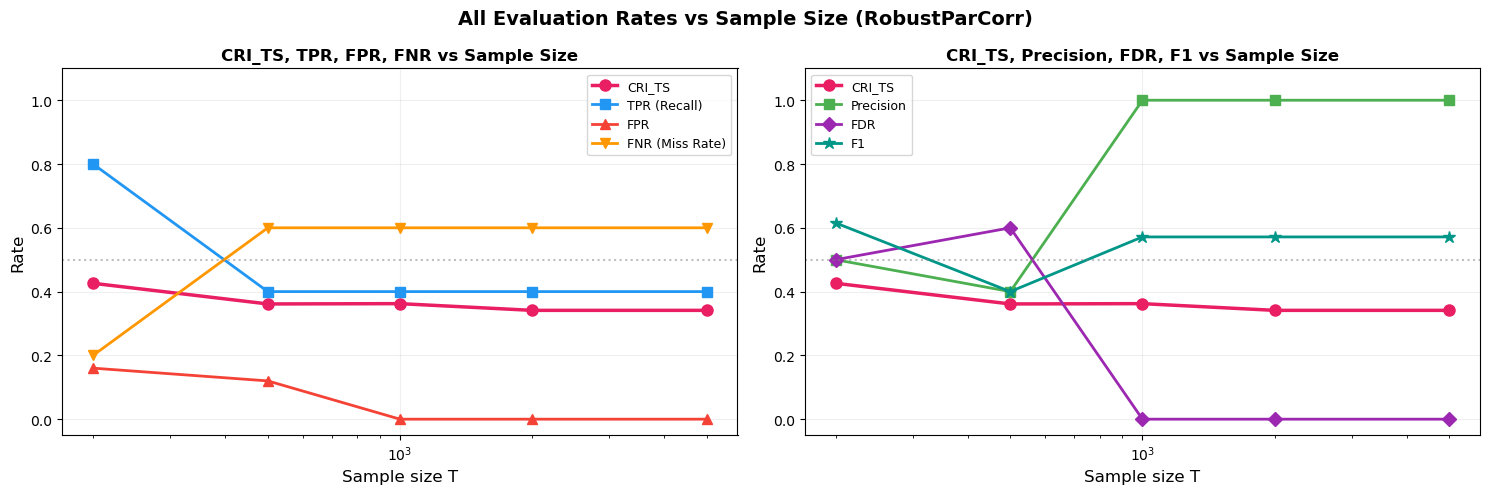


Correlations with CRI_TS:
  CRI vs TPR         : r = +0.956
  CRI vs FPR         : r = +0.821
  CRI vs FNR         : r = -0.956
  CRI vs TNR         : r = -0.821
  CRI vs FDR         : r = +0.632
  CRI vs precision   : r = -0.632
  CRI vs F1          : r = +0.299


In [45]:
# === ALL RATES across sample sizes ===

d = len(available_vars)
n_possible = d * (d - 1)

# Recompute all rates safely
results_T_df['TN'] = n_possible - results_T_df['TP'] - results_T_df['FP'] - results_T_df['FN']
results_T_df['TPR'] = results_T_df.apply(
    lambda r: r['TP']/(r['TP']+r['FN']) if (r['TP']+r['FN'])>0 else 0.0, axis=1)
results_T_df['FPR'] = results_T_df.apply(
    lambda r: r['FP']/(r['FP']+r['TN']) if (r['FP']+r['TN'])>0 else 0.0, axis=1)
results_T_df['FNR'] = results_T_df.apply(
    lambda r: r['FN']/(r['FN']+r['TP']) if (r['FN']+r['TP'])>0 else 0.0, axis=1)
results_T_df['TNR'] = results_T_df.apply(
    lambda r: r['TN']/(r['TN']+r['FP']) if (r['TN']+r['FP'])>0 else 0.0, axis=1)
results_T_df['FDR'] = results_T_df.apply(
    lambda r: r['FP']/(r['FP']+r['TP']) if (r['FP']+r['TP'])>0 else 0.0, axis=1)

# Full table
print("=" * 90)
print("  FULL METRICS TABLE")
print("=" * 90)
print(f"{'T':>6}  {'CRI_TS':>7}  {'TPR':>6}  {'FPR':>6}  {'FNR':>6}  {'TNR':>6}  "
      f"{'FDR':>6}  {'Prec':>6}  {'F1':>6}  {'TP':>3}  {'FP':>3}  {'FN':>3}  {'TN':>3}")
print("-" * 90)
for _, row in results_T_df.iterrows():
    print(f"{int(row['T']):>6}  {row['CRI_TS']:>7.4f}  {row['TPR']:>6.3f}  {row['FPR']:>6.3f}  "
          f"{row['FNR']:>6.3f}  {row['TNR']:>6.3f}  {row['FDR']:>6.3f}  "
          f"{row['precision']:>6.3f}  {row['F1']:>6.3f}  {int(row['TP']):>3}  "
          f"{int(row['FP']):>3}  {int(row['FN']):>3}  {int(row['TN']):>3}")

# === PLOT: All rates vs T ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: CRI + TPR + FPR + FNR
axes[0].plot(results_T_df['T'], results_T_df['CRI_TS'], 'o-', color='#E91E63', lw=2.5, ms=8, label='CRI_TS')
axes[0].plot(results_T_df['T'], results_T_df['TPR'], 's-', color='#2196F3', lw=2, ms=7, label='TPR (Recall)')
axes[0].plot(results_T_df['T'], results_T_df['FPR'], '^-', color='#F44336', lw=2, ms=7, label='FPR')
axes[0].plot(results_T_df['T'], results_T_df['FNR'], 'v-', color='#FF9800', lw=2, ms=7, label='FNR (Miss Rate)')
axes[0].axhline(0.5, color='gray', ls=':', alpha=0.5)
axes[0].set_xscale('log')
axes[0].set_xlabel('Sample size T', fontsize=12)
axes[0].set_ylabel('Rate', fontsize=12)
axes[0].set_ylim(-0.05, 1.1)
axes[0].legend(fontsize=9)
axes[0].set_title('CRI_TS, TPR, FPR, FNR vs Sample Size', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.2)

# Panel 2: CRI + Precision + FDR + F1
axes[1].plot(results_T_df['T'], results_T_df['CRI_TS'], 'o-', color='#E91E63', lw=2.5, ms=8, label='CRI_TS')
axes[1].plot(results_T_df['T'], results_T_df['precision'], 's-', color='#4CAF50', lw=2, ms=7, label='Precision')
axes[1].plot(results_T_df['T'], results_T_df['FDR'], 'D-', color='#9C27B0', lw=2, ms=7, label='FDR')
axes[1].plot(results_T_df['T'], results_T_df['F1'], '*-', color='#009688', lw=2, ms=9, label='F1')
axes[1].axhline(0.5, color='gray', ls=':', alpha=0.5)
axes[1].set_xscale('log')
axes[1].set_xlabel('Sample size T', fontsize=12)
axes[1].set_ylabel('Rate', fontsize=12)
axes[1].set_ylim(-0.05, 1.1)
axes[1].legend(fontsize=9)
axes[1].set_title('CRI_TS, Precision, FDR, F1 vs Sample Size', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.2)

plt.suptitle('All Evaluation Rates vs Sample Size (RobustParCorr)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_all_rates_vs_T.png"), dpi=150, bbox_inches='tight')
plt.show()

# Correlations with CRI
print("\nCorrelations with CRI_TS:")
for metric in ['TPR', 'FPR', 'FNR', 'TNR', 'FDR', 'precision', 'F1']:
    r = np.corrcoef(results_T_df['CRI_TS'], results_T_df[metric])[0, 1]
    print(f"  CRI vs {metric:<12s}: r = {r:+.3f}")

In [46]:
# === Diagnostic: what's happening as T grows? ===
print(f"True edges in ground truth: {int(gt_adj.sum())}")
print(f"Total possible edges: {d*(d-1)}")
print()
print(f"{'T':>6}  {'TP':>4}  {'FP':>4}  {'FN':>4}  {'TN':>4}  {'Disc':>5}  {'CRI':>7}  {'Prec':>6}  {'TPR':>6}  {'FPR':>6}")
print("-" * 75)
for _, row in results_T_df.iterrows():
    n_disc = int(row['TP'] + row['FP'])
    print(f"{int(row['T']):>6}  {int(row['TP']):>4}  {int(row['FP']):>4}  {int(row['FN']):>4}  "
          f"{int(row['TN']):>4}  {n_disc:>5}  {row['CRI_TS']:>7.4f}  "
          f"{row['precision']:>6.3f}  {row['TPR']:>6.3f}  {row['FPR']:>6.3f}")

True edges in ground truth: 5
Total possible edges: 30

     T    TP    FP    FN    TN   Disc      CRI    Prec     TPR     FPR
---------------------------------------------------------------------------
   200     4     4     1    21      8   0.4260   0.500   0.800   0.160
   500     2     3     3    22      5   0.3613   0.400   0.400   0.120
  1000     2     0     3    25      2   0.3622   1.000   0.400   0.000
  2000     2     0     3    25      2   0.3412   1.000   0.400   0.000
  5000     2     0     3    25      2   0.3412   1.000   0.400   0.000


### downsampling to fix the fact that CRI is decreasing as it should be increasing

In [47]:
# === Compare: no downsampling vs downsampling ===
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.robust_parcorr import RobustParCorr
import time

TAU_MAX = 5
T = 2000
gt_edges_set = set(tuple(e) for e in GT_EDGES)

comparison_rows = []

for ds_factor, ds_label in [(1, "No downsample (7Hz)"), 
                             (2, "Downsample ×2 (3.5Hz)"),
                             (4, "Downsample ×4 (1.75Hz)"),
                             (7, "Downsample ×7 (1Hz)")]:
    
    df_sub = df_full[available_vars].iloc[::ds_factor].reset_index(drop=True).iloc[:T]
    df_sub["pressure_ambient"] = df_sub["pressure_ambient"].diff()
    df_sub = df_sub.iloc[1:].reset_index(drop=True)
    data_array = df_sub.values.astype(np.float64)
    dataframe = pp.DataFrame(data_array, var_names=available_vars)
    
    parcorr = RobustParCorr(significance='analytic')
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)
    
    t0 = time.time()
    res = pcmci.run_pcmciplus(tau_min=0, tau_max=TAU_MAX, pc_alpha=0.2)
    elapsed = time.time() - t0
    
    g = res['graph']
    p_mat = res['p_matrix']
    d = len(available_vars)
    
    # Summary adjacency
    learned = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(d):
            for tau in range(1, TAU_MAX+1):
                if g[i, j, tau] == '-->':
                    learned[i, j] = 1
    
    # Metrics
    mask = ~np.eye(d, dtype=bool)
    g_f = gt_adj[mask].flatten()
    l_f = learned[mask].flatten()
    TP = int(((g_f==1)&(l_f==1)).sum())
    FP = int(((g_f==0)&(l_f==1)).sum())
    FN = int(((g_f==1)&(l_f==0)).sum())
    TN = int(((g_f==0)&(l_f==0)).sum())
    
    prec = TP/(TP+FP) if (TP+FP) > 0 else 0
    rec  = TP/(TP+FN) if (TP+FN) > 0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    fpr  = FP/(FP+TN) if (FP+TN) > 0 else 0
    
    # CRI
    pvs = []
    for i in range(d):
        for j in range(d):
            if i == j: continue
            for tau in range(1, TAU_MAX+1):
                pvs.append(p_mat[i, j, tau])
    pvs = np.array(pvs)
    cri = 1.0 - pvs.mean()
    
    comparison_rows.append({
        'Downsample': ds_label, 'ds_factor': ds_factor,
        'CRI_TS': cri, 'TPR': rec, 'FPR': fpr, 'Precision': prec,
        'F1': f1, 'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
        'mean_p': pvs.mean(), 'time': elapsed,
    })
    
    print(f"{ds_label:>25s}: CRI={cri:.4f}  TP={TP}  FP={FP}  FN={FN}  "
          f"TPR={rec:.3f}  FPR={fpr:.3f}  Prec={prec:.3f}")

comp_df = pd.DataFrame(comparison_rows)
comp_df

      No downsample (7Hz): CRI=0.3412  TP=2  FP=0  FN=3  TPR=0.400  FPR=0.000  Prec=1.000
    Downsample ×2 (3.5Hz): CRI=0.3940  TP=3  FP=1  FN=2  TPR=0.600  FPR=0.040  Prec=0.750
   Downsample ×4 (1.75Hz): CRI=0.3792  TP=2  FP=1  FN=3  TPR=0.400  FPR=0.040  Prec=0.667
      Downsample ×7 (1Hz): CRI=0.4216  TP=2  FP=1  FN=3  TPR=0.400  FPR=0.040  Prec=0.667


,Downsample,ds_factor,CRI_TS,TPR,FPR,Precision,F1,TP,FP,FN,TN,mean_p,time
0,No downsample (7Hz),1,0.341186,0.4,0.00,1.000000,0.571429,2,0,3,25,0.658814,3.287960
1,Downsample ×2 (3.5Hz),2,0.394042,0.6,0.04,0.750000,0.666667,3,1,2,24,0.605958,1.773742
2,Downsample ×4 (1.75Hz),4,0.379199,0.4,0.04,0.666667,0.500000,2,1,3,24,0.620801,1.455730
3,Downsample ×7 (1Hz),7,0.421644,0.4,0.04,0.666667,0.500000,2,1,3,24,0.578356,1.056305


### Run PCMCI+

In [48]:
# === PCMCI+ with GPDC ===
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.gpdc import GPDC
import time
import numpy as np

DS_FACTOR = 2
T = 1000
TAU_MAX = 5

df_sub = df_full[available_vars].iloc[::DS_FACTOR].reset_index(drop=True).iloc[:T]
data_array = df_sub.values.astype(np.float64)
dataframe = pp.DataFrame(data_array, var_names=available_vars)

print(f"Data: {df_sub.shape}, tau_max={TAU_MAX}")
print(f"Running PCMCI+ with GPDC — this will take a few minutes...\n")

gpdc = GPDC(significance='analytic', gp_params=None)
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=gpdc, verbosity=2)

t0 = time.time()
results_gpdc = pcmci.run_pcmciplus(tau_min=0, tau_max=TAU_MAX, pc_alpha=0.2)
elapsed = time.time() - t0

graph = results_gpdc['graph']
p_matrix = results_gpdc['p_matrix']
val_matrix = results_gpdc['val_matrix']
d = len(available_vars)

print(f"\nDone in {elapsed:.1f}s")

# Discovered edges
print("\n=== Discovered edges (GPDC) ===")
for i in range(d):
    for j in range(d):
        for tau in range(0, TAU_MAX+1):
            if graph[i, j, tau] in ['-->', 'o-o', '<->']:
                if tau > 0:
                    print(f"  {available_vars[i]}(t-{tau}) --> {available_vars[j]}(t)  p={p_matrix[i,j,tau]:.6f}")
                else:
                    print(f"  {available_vars[i]}(t) {graph[i,j,0]} {available_vars[j]}(t)  p={p_matrix[i,j,0]:.6f}")

# Metrics
learned = np.zeros((d, d), dtype=int)
for i in range(d):
    for j in range(d):
        for tau in range(1, TAU_MAX+1):
            if graph[i, j, tau] == '-->':
                learned[i, j] = 1

mask = ~np.eye(d, dtype=bool)
g_f = gt_adj[mask].flatten()
l_f = learned[mask].flatten()
TP = int(((g_f==1)&(l_f==1)).sum())
FP = int(((g_f==0)&(l_f==1)).sum())
FN = int(((g_f==1)&(l_f==0)).sum())
TN = int(((g_f==0)&(l_f==0)).sum())
prec = TP/(TP+FP) if (TP+FP) > 0 else 0
rec  = TP/(TP+FN) if (TP+FN) > 0 else 0
f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
fpr  = FP/(FP+TN) if (FP+TN) > 0 else 0

# CRI
pvs_gpdc = []
for i in range(d):
    for j in range(d):
        if i == j: continue
        for tau in range(1, TAU_MAX+1):
            pvs_gpdc.append(p_matrix[i, j, tau])
pvs_gpdc = np.array(pvs_gpdc)
cri_gpdc = 1.0 - pvs_gpdc.mean()

print(f"\n{'='*55}")
print(f"  GPDC Results (T={T}, ds=×{DS_FACTOR})")
print(f"{'='*55}")
print(f"  CRI_TS:     {cri_gpdc:.4f}")
print(f"  TP={TP}  FP={FP}  FN={FN}  TN={TN}")
print(f"  Precision:  {prec:.4f}")
print(f"  TPR:        {rec:.4f}")
print(f"  F1:         {f1:.4f}")
print(f"  FPR:        {fpr:.4f}")
print(f"{'='*55}")

Data: (508, 6), tau_max=5
Running PCMCI+ with GPDC — this will take a few minutes...


##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = gp_dc
tau_min = 1
tau_max = 5
pc_alpha = [0.2]
max_conds_dim = None
max_combinations = 1



## Variable load_in

Iterating through pc_alpha = [0.2]:

# pc_alpha = 0.2 (1/1):

Testing condition sets of dimension 0:

    Link (load_in -1) -?> load_in (1/30):
    Subset 0: () gives pval = 0.00000 / val =  0.995
    No conditions of dimension 0 left.

    Link (load_in -2) -?> load_in (2/30):
    Subset 0: () gives pval = 0.00000 / val =  0.989
    No conditions of dimension 0 left.

    Link (load_in -3) -?> load_in (3/30):
    Subset 0: () gives pval = 0.00000 / val =  0.982
    No conditions of dimension 0 left.

    Link (load_in -4) -?> load_in (4/30):
    Subset 0: () gives pval = 0.00000 / val =  0.973
    No conditions of dimension 0 left.

    Link (load_in -5) -?> load_in (5/30):
    Subset 0: () giv

c:\Users\Lenovo Gaming\anaconda3\envs\my_env\Lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


    Subset 2: (load_out 0) (rpm_in 0)  gives pval = 0.02400 / val =  0.112
    No conditions of dimension 2 left.

    Link (rpm_in -1) -?> rpm_in (11/20):
    Iterate through 1 subset(s) of conditions: 
    with conds_y = [ (load_in -1) (load_in -4) (rpm_in -3) (pressure_downwind -1) ]
    with conds_x = [ (load_in -2) (rpm_in -2) (load_in -5) (rpm_in -4) (pressure_downwind -2) ]
    Subset 0: (load_in 0) (pressure_downwind 0)  gives pval = 0.00000 / val =  0.572
    No conditions of dimension 2 left.

    Link (rpm_in  0) o?o pressure_downwind (12/20):
    Iterate through 1 subset(s) of conditions: 
    with conds_y = [ (pressure_downwind -1) (pressure_downwind -2) (load_out -1) (load_in -1) (rpm_in -5) ]
    with conds_x = [ (load_in -1) (rpm_in -1) (load_in -4) (rpm_in -3) (pressure_downwind -1) ]
    Subset 0: (rpm_out 0) (load_out 0)  gives pval = 0.01800 / val =  0.117
    No conditions of dimension 2 left.

    Link (rpm_in -5) -?> pressure_downwind (13/20):
    Iterate through

c:\Users\Lenovo Gaming\anaconda3\envs\my_env\Lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 9 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


    Subset 0: (load_out 0) (rpm_in 0)  gives pval = 0.39200 / val =  0.070
    Subset 1: () gives pval = 0.14400 / val =  0.086
    Subset 2: (load_out 0)  gives pval = 0.52000 / val =  0.064
    Subset 3: (rpm_in 0)  gives pval = 0.10000 / val =  0.093
    Subset 4: (pressure_downwind 0)  gives pval = 0.17800 / val =  0.082
    Subset 5: (load_out 0) (pressure_downwind 0)  gives pval = 0.60200 / val =  0.061
    Fraction of separating subsets containing (load_out 0) is > 0.5 --> non-collider found

    Triple (pressure_downwind  0) o-o load_out o-o load_in (4/36)
    Iterate through 8 condition subset(s) of neighbors: 
    with conds_y = [ (load_in -1) (load_in -3) ]
    with conds_x = [ (pressure_downwind -1) (pressure_downwind -2) (load_out -1) (load_in -1) (rpm_in -5) ]
    Subset 0: (load_out 0) (rpm_in 0)  gives pval = 0.23800 / val =  0.078
    Subset 1: () gives pval = 0.33000 / val =  0.073
    Subset 2: (load_out 0)  gives pval = 0.32600 / val =  0.073
    Subset 3: (rpm_in 0

In [49]:
print(f"Total rows in df_full: {len(df_full)}")
print(f"With ds=2: {len(df_full)//2}")
print(f"With ds=1 (no ds): {len(df_full)}")

Total rows in df_full: 1016
With ds=2: 508
With ds=1 (no ds): 1016


In [50]:
# === Run all 3 CI tests on full data (no downsampling) ===
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
import time

TAU_MAX = 5
T = 1016  # full dataset, no downsampling

df_sub = df_full[available_vars].iloc[:T].reset_index(drop=True)
df_sub["pressure_ambient"] = df_sub["pressure_ambient"].diff()
df_sub = df_sub.iloc[1:].reset_index(drop=True)
data_array = df_sub.values.astype(np.float64)

d = len(available_vars)
n_candidate = d * (d-1) * TAU_MAX
gt_edges_set = set(tuple(e) for e in GT_EDGES)

print(f"Data: {df_sub.shape}, tau_max={TAU_MAX}")
print(f"True edges: {int(gt_adj.sum())}, Candidate edges: {n_candidate}\n")

# Define all CI tests
ci_tests = {
    "RobustParCorr": RobustParCorr(significance='analytic'),
    "GPDC": GPDC(significance='analytic', gp_params=None),
    "CMIknn": CMIknn(knn=0.1, shuffle_neighbors=5, significance='shuffle_test', sig_samples=200),
}

all_ci_results = {}

for test_name, ci_test in ci_tests.items():
    print(f"\n{'='*60}")
    print(f"  Running PCMCI+ with {test_name}...")
    print(f"{'='*60}")
    
    dataframe = pp.DataFrame(data_array, var_names=available_vars)
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=ci_test, verbosity=0)
    
    t0 = time.time()
    res = pcmci.run_pcmciplus(tau_min=0, tau_max=TAU_MAX, pc_alpha=0.2)
    elapsed = time.time() - t0
    
    graph = res['graph']
    p_mat = res['p_matrix']
    val_mat = res['val_matrix']
    
    # Summary adjacency
    learned = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(d):
            for tau in range(1, TAU_MAX+1):
                if graph[i, j, tau] == '-->':
                    learned[i, j] = 1
    
    # Metrics
    mask = ~np.eye(d, dtype=bool)
    g_f = gt_adj[mask].flatten()
    l_f = learned[mask].flatten()
    TP = int(((g_f==1)&(l_f==1)).sum())
    FP = int(((g_f==0)&(l_f==1)).sum())
    FN = int(((g_f==1)&(l_f==0)).sum())
    TN = int(((g_f==0)&(l_f==0)).sum())
    prec = TP/(TP+FP) if (TP+FP) > 0 else 0
    rec  = TP/(TP+FN) if (TP+FN) > 0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    fpr  = FP/(FP+TN) if (FP+TN) > 0 else 0
    fnr  = FN/(FN+TP) if (FN+TP) > 0 else 0
    tnr  = TN/(TN+FP) if (TN+FP) > 0 else 0
    fdr  = FP/(FP+TP) if (FP+TP) > 0 else 0
    
    # CRI
    pvs = []
    for i in range(d):
        for j in range(d):
            if i == j: continue
            for tau in range(1, TAU_MAX+1):
                pvs.append(p_mat[i, j, tau])
    pvs = np.array(pvs)
    cri = 1.0 - pvs.mean()
    
    # P-value split
    p_true_list, p_absent_list = [], []
    for i in range(d):
        for j in range(d):
            if i == j: continue
            for tau in range(1, TAU_MAX+1):
                src, tgt = available_vars[i], available_vars[j]
                if (src, tgt) in gt_edges_set:
                    p_true_list.append(p_mat[i, j, tau])
                else:
                    p_absent_list.append(p_mat[i, j, tau])
    
    # Discovered edges list
    disc_edges = []
    for i in range(d):
        for j in range(d):
            for tau in range(1, TAU_MAX+1):
                if graph[i, j, tau] == '-->':
                    disc_edges.append(f"{available_vars[i]}(t-{tau})->{available_vars[j]}")
    
    all_ci_results[test_name] = {
        'graph': graph, 'p_matrix': p_mat, 'val_matrix': val_mat,
        'pvalues': pvs, 'learned_adj': learned, 'elapsed': elapsed,
        'CRI_TS': cri, 'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
        'TPR': rec, 'FPR': fpr, 'FNR': fnr, 'TNR': tnr, 'FDR': fdr,
        'precision': prec, 'recall': rec, 'F1': f1, 'SHD': FP+FN,
        'mean_p_true': np.mean(p_true_list), 'mean_p_absent': np.mean(p_absent_list),
        'disc_edges': disc_edges,
    }
    
    print(f"  Done in {elapsed:.1f}s")
    print(f"  CRI={cri:.4f}  TP={TP} FP={FP} FN={FN}  TPR={rec:.3f} FPR={fpr:.3f} Prec={prec:.3f} F1={f1:.3f}")
    print(f"  Edges: {disc_edges}")

print(f"\n\nAll 3 tests complete!")

Data: (1015, 6), tau_max=5
True edges: 5, Candidate edges: 150


  Running PCMCI+ with RobustParCorr...
  Done in 3.8s
  CRI=0.3412  TP=2 FP=0 FN=3  TPR=0.400 FPR=0.000 Prec=1.000 F1=0.571
  Edges: ['load_in(t-1)->load_in', 'load_in(t-2)->load_in', 'load_in(t-4)->load_in', 'load_in(t-2)->rpm_in', 'load_in(t-4)->rpm_in', 'load_in(t-5)->rpm_in', 'load_out(t-1)->load_out', 'load_out(t-2)->load_out', 'load_out(t-1)->rpm_out', 'load_out(t-2)->rpm_out', 'load_out(t-3)->rpm_out', 'load_out(t-4)->rpm_out', 'rpm_in(t-1)->rpm_in', 'rpm_in(t-2)->rpm_in', 'rpm_out(t-1)->rpm_out', 'pressure_downwind(t-1)->pressure_downwind', 'pressure_downwind(t-2)->pressure_downwind', 'pressure_downwind(t-3)->pressure_downwind', 'pressure_ambient(t-1)->pressure_ambient', 'pressure_ambient(t-5)->pressure_ambient']

  Running PCMCI+ with GPDC...


c:\Users\Lenovo Gaming\anaconda3\envs\my_env\Lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 9 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\Lenovo Gaming\anaconda3\envs\my_env\Lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 7 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


  Done in 3148.8s
  CRI=0.3812  TP=2 FP=4 FN=3  TPR=0.400 FPR=0.160 Prec=0.333 F1=0.364
  Edges: ['load_in(t-1)->load_in', 'load_in(t-5)->load_in', 'load_in(t-1)->rpm_in', 'load_in(t-2)->rpm_in', 'load_in(t-1)->pressure_downwind', 'load_out(t-1)->load_out', 'load_out(t-3)->load_out', 'load_out(t-1)->rpm_out', 'load_out(t-2)->rpm_out', 'load_out(t-3)->rpm_out', 'load_out(t-1)->pressure_downwind', 'rpm_in(t-1)->rpm_in', 'rpm_out(t-1)->rpm_out', 'rpm_out(t-4)->rpm_out', 'pressure_downwind(t-1)->rpm_in', 'pressure_downwind(t-3)->rpm_in', 'pressure_downwind(t-3)->rpm_out', 'pressure_downwind(t-1)->pressure_downwind', 'pressure_downwind(t-2)->pressure_downwind', 'pressure_downwind(t-3)->pressure_downwind', 'pressure_downwind(t-4)->pressure_downwind', 'pressure_ambient(t-1)->pressure_ambient', 'pressure_ambient(t-5)->pressure_ambient']

  Running PCMCI+ with CMIknn...
  Done in 1734.7s
  CRI=0.2633  TP=1 FP=0 FN=4  TPR=0.200 FPR=0.000 Prec=1.000 F1=0.333
  Edges: ['load_in(t-1)->load_in', 'lo

In [51]:
# === COMPARISON TABLE ===
comp_rows = []
for name in ['RobustParCorr', 'GPDC', 'CMIknn']:
    r = all_ci_results[name]
    comp_rows.append({
        'CI Test': name,
        'CRI_TS': r['CRI_TS'],
        'TPR': r['TPR'],
        'FPR': r['FPR'],
        'FNR': r['FNR'],
        'TNR': r['TNR'],
        'FDR': r['FDR'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1': r['F1'],
        'SHD': r['SHD'],
        'TP': r['TP'],
        'FP': r['FP'],
        'FN': r['FN'],
        'TN': r['TN'],
        'Mean p (true)': r['mean_p_true'],
        'Mean p (absent)': r['mean_p_absent'],
        'Time (s)': round(r['elapsed'], 1),
    })

comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(os.path.join(RESULTS_DIR, "ci_test_comparison.csv"), index=False)

# Display with styling
float_cols = ['CRI_TS','TPR','FPR','FNR','TNR','FDR','Precision','Recall','F1','Mean p (true)','Mean p (absent)']
styled = comp_df.style.format({c: '{:.4f}' for c in float_cols}).format({'Time (s)': '{:.1f}'}).set_caption(
    f"PCMCI+ Comparison — T={T}, τ_max={TAU_MAX}, pc_alpha=0.2"
).applymap(
    lambda v: 'background-color: #C8E6C9' if isinstance(v, float) and v >= 0.5 else
              'background-color: #FFF9C4' if isinstance(v, float) and v >= 0.3 else
              'background-color: #FFCDD2' if isinstance(v, float) and v < 0.3 else '',
    subset=['CRI_TS', 'TPR', 'Precision', 'F1']
).applymap(
    lambda v: 'background-color: #C8E6C9' if isinstance(v, float) and v <= 0.1 else
              'background-color: #FFF9C4' if isinstance(v, float) and v <= 0.2 else
              'background-color: #FFCDD2' if isinstance(v, float) and v > 0.2 else '',
    subset=['FPR', 'FDR']
)
styled

C:\Users\Lenovo Gaming\AppData\Local\Temp\ipykernel_21256\714716003.py:33: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  ).applymap(
C:\Users\Lenovo Gaming\AppData\Local\Temp\ipykernel_21256\714716003.py:38: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  ).applymap(


,CI Test,CRI_TS,TPR,FPR,FNR,TNR,FDR,Precision,Recall,F1,SHD,TP,FP,FN,TN,Mean p (true),Mean p (absent),Time (s)
0,RobustParCorr,0.341186,0.400000,0.000000,0.600000,1.000000,0.000000,1.000000,0.400000,0.571429,3,2,0,3,25,0.400776,0.710421,3.8
1,GPDC,0.381227,0.400000,0.160000,0.600000,0.840000,0.666667,0.333333,0.400000,0.363636,7,2,4,3,21,0.506800,0.641168,3148.8
2,CMIknn,0.263284,0.200000,0.000000,0.800000,1.000000,0.000000,1.000000,0.200000,0.333333,4,1,0,4,25,0.720199,0.740020,1734.7


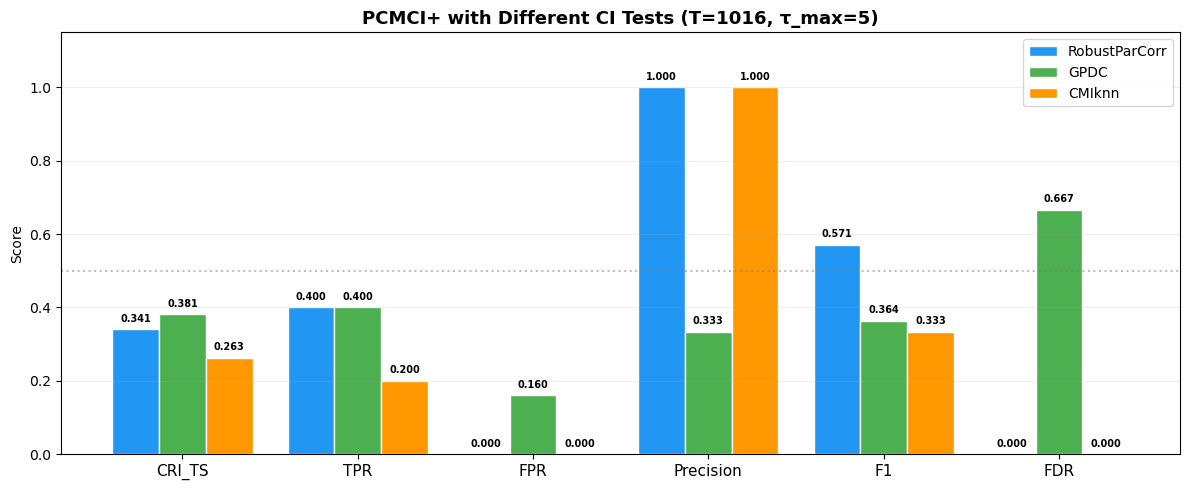

In [52]:
# === COMPARISON BAR CHART ===
metrics_to_plot = ['CRI_TS', 'TPR', 'FPR', 'Precision', 'F1', 'FDR']
colors_tests = {'RobustParCorr': '#2196F3', 'GPDC': '#4CAF50', 'CMIknn': '#FF9800'}
test_names = list(all_ci_results.keys())
n_tests = len(test_names)
n_metrics = len(metrics_to_plot)
x = np.arange(n_metrics)
width = 0.8 / n_tests

fig, ax = plt.subplots(figsize=(12, 5))
for idx, name in enumerate(test_names):
    r = all_ci_results[name]
    vals = [r.get(m, comp_df[comp_df['CI Test']==name][m].values[0]) for m in metrics_to_plot]
    offset = (idx - n_tests/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=name,
                  color=colors_tests.get(name, 'gray'), edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.3f}', ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='gray', ls=':', alpha=0.5)
ax.legend(fontsize=10)
ax.set_title(f'PCMCI+ with Different CI Tests (T={T}, τ_max={TAU_MAX})',
             fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_ci_test_comparison.png"), dpi=150)
plt.show()

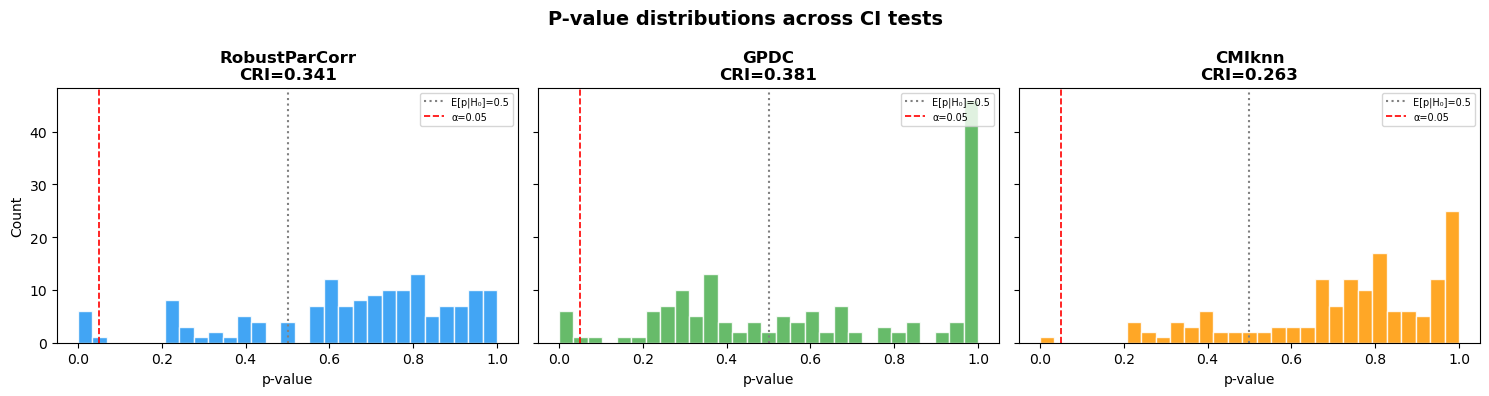

In [53]:
# === PLOT 1: P-value distributions for all 3 tests ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors_tests = {'RobustParCorr': '#2196F3', 'GPDC': '#4CAF50', 'CMIknn': '#FF9800'}
bins = np.linspace(0, 1, 30)

for idx, name in enumerate(['RobustParCorr', 'GPDC', 'CMIknn']):
    pv = all_ci_results[name]['pvalues']
    axes[idx].hist(pv, bins=bins, color=colors_tests[name], edgecolor='white', alpha=0.85)
    axes[idx].axvline(0.5, color='gray', ls=':', lw=1.5, label='E[p|H₀]=0.5')
    axes[idx].axvline(0.05, color='red', ls='--', lw=1.2, label='α=0.05')
    axes[idx].set_title(f"{name}\nCRI={all_ci_results[name]['CRI_TS']:.3f}", 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('p-value')
    axes[idx].legend(fontsize=7)
    if idx == 0: axes[idx].set_ylabel('Count')

plt.suptitle('P-value distributions across CI tests', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_pvalue_distributions.png"), dpi=150, bbox_inches='tight')
plt.show()

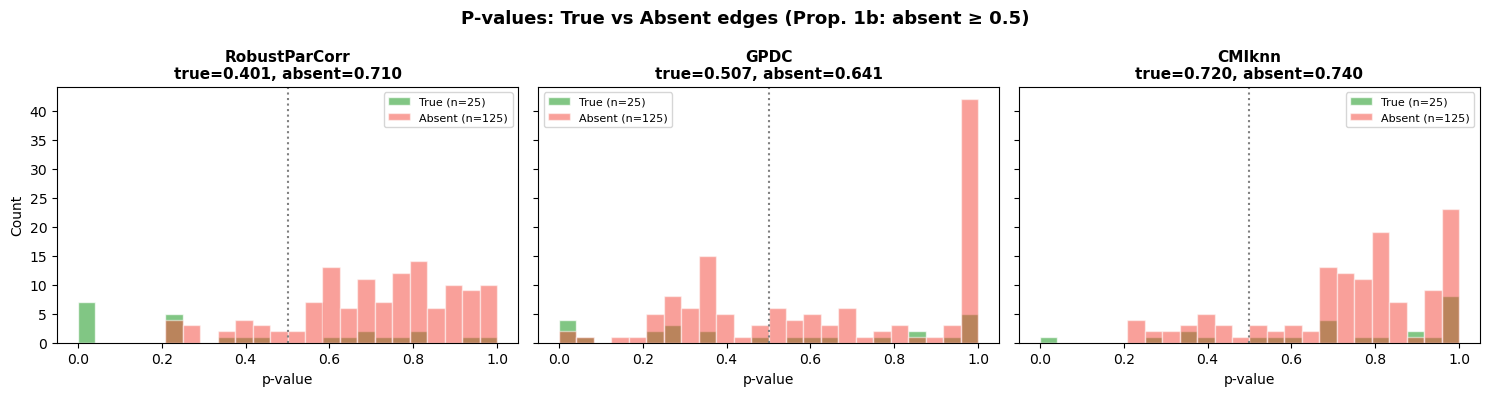

In [54]:
# === PLOT 2: P-values true vs absent edges (Proposition 1b) ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bins = np.linspace(0, 1, 25)

for idx, name in enumerate(['RobustParCorr', 'GPDC', 'CMIknn']):
    r = all_ci_results[name]
    p_mat = r['p_matrix']
    p_true, p_absent = [], []
    
    for i in range(d):
        for j in range(d):
            if i == j: continue
            for tau in range(1, TAU_MAX+1):
                if (available_vars[i], available_vars[j]) in gt_edges_set:
                    p_true.append(p_mat[i, j, tau])
                else:
                    p_absent.append(p_mat[i, j, tau])
    
    axes[idx].hist(p_true, bins=bins, alpha=0.7, color='#4CAF50',
                   label=f'True (n={len(p_true)})', edgecolor='white')
    axes[idx].hist(p_absent, bins=bins, alpha=0.5, color='#F44336',
                   label=f'Absent (n={len(p_absent)})', edgecolor='white')
    axes[idx].axvline(0.5, color='gray', ls=':', lw=1.5)
    axes[idx].set_title(f"{name}\ntrue={np.mean(p_true):.3f}, absent={np.mean(p_absent):.3f}",
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('p-value')
    axes[idx].legend(fontsize=8)
    if idx == 0: axes[idx].set_ylabel('Count')

plt.suptitle('P-values: True vs Absent edges (Prop. 1b: absent ≥ 0.5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_pval_true_vs_absent.png"), dpi=150, bbox_inches='tight')
plt.show()

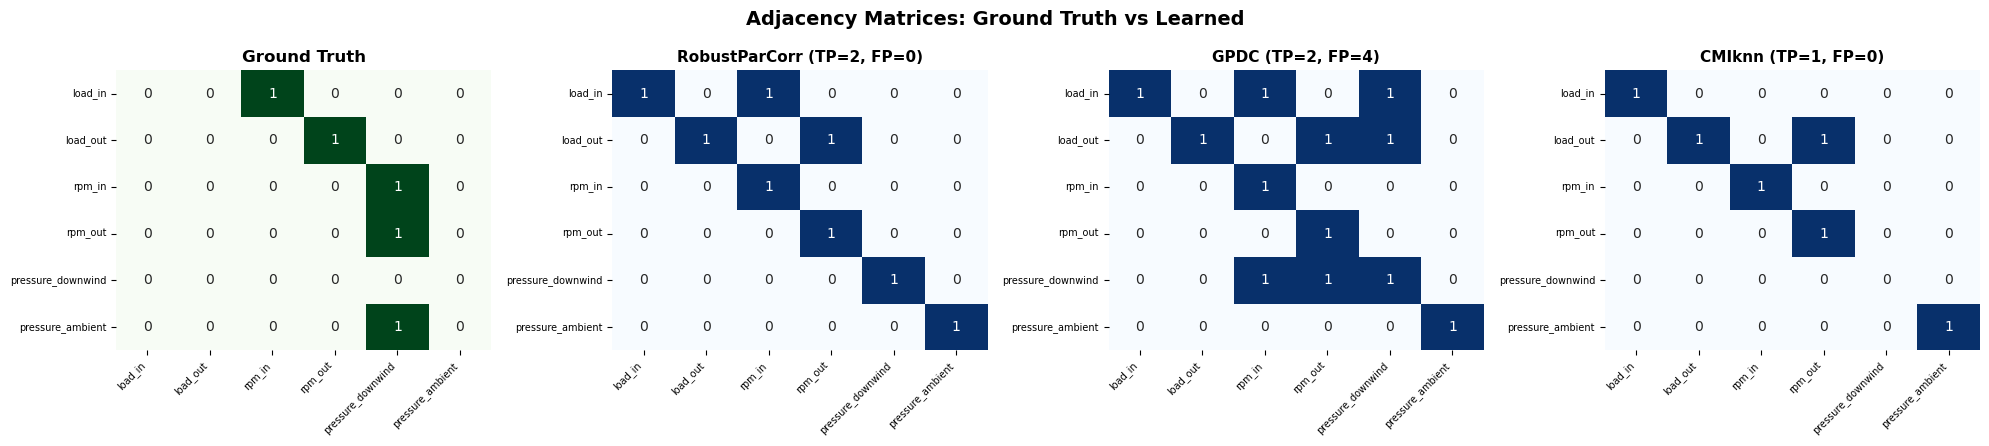

In [55]:
# === PLOT 3: Ground truth vs learned adjacency for each test ===
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
import seaborn as sns

sns.heatmap(gt_adj, annot=True, fmt='d', cmap='Greens', vmin=0, vmax=1, cbar=False,
            xticklabels=available_vars, yticklabels=available_vars, ax=axes[0])
axes[0].set_title('Ground Truth', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(available_vars, rotation=45, ha='right', fontsize=7)
axes[0].set_yticklabels(available_vars, rotation=0, fontsize=7)

for idx, name in enumerate(['RobustParCorr', 'GPDC', 'CMIknn']):
    r = all_ci_results[name]
    sns.heatmap(r['learned_adj'], annot=True, fmt='d', cmap='Blues', vmin=0, vmax=1, cbar=False,
                xticklabels=available_vars, yticklabels=available_vars, ax=axes[idx+1])
    axes[idx+1].set_title(f"{name} (TP={r['TP']}, FP={r['FP']})", fontsize=11, fontweight='bold')
    axes[idx+1].set_xticklabels(available_vars, rotation=45, ha='right', fontsize=7)
    axes[idx+1].set_yticklabels(available_vars, rotation=0, fontsize=7)

plt.suptitle('Adjacency Matrices: Ground Truth vs Learned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_adjacency_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

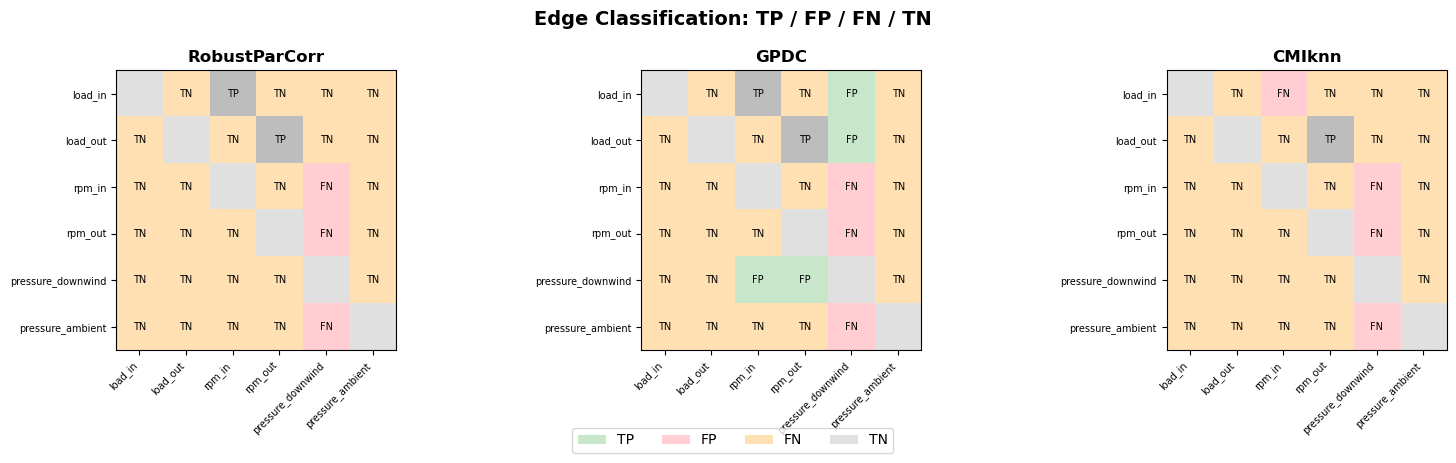

In [56]:
# === PLOT 4: Edge comparison — color coded (TP/FP/FN/TN) ===
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for idx, name in enumerate(['RobustParCorr', 'GPDC', 'CMIknn']):
    r = all_ci_results[name]
    learned = r['learned_adj']
    
    # 0=TN(gray), 1=TP(green), 2=FP(red), 3=FN(orange)
    color_mat = np.zeros((d, d))
    for i in range(d):
        for j in range(d):
            if i == j:
                color_mat[i, j] = -1  # diagonal
            elif gt_adj[i, j] == 1 and learned[i, j] == 1:
                color_mat[i, j] = 3  # TP
            elif gt_adj[i, j] == 0 and learned[i, j] == 1:
                color_mat[i, j] = 2  # FP
            elif gt_adj[i, j] == 1 and learned[i, j] == 0:
                color_mat[i, j] = 1  # FN
            else:
                color_mat[i, j] = 0  # TN
    
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['#E0E0E0', '#FFE0B2', '#FFCDD2', '#C8E6C9', '#BDBDBD'])
    
    im = axes[idx].imshow(color_mat, cmap=cmap, vmin=-1, vmax=3)
    axes[idx].set_xticks(range(d))
    axes[idx].set_yticks(range(d))
    axes[idx].set_xticklabels(available_vars, rotation=45, ha='right', fontsize=7)
    axes[idx].set_yticklabels(available_vars, fontsize=7)
    axes[idx].set_title(f"{name}", fontsize=12, fontweight='bold')
    
    # Annotate
    for i in range(d):
        for j in range(d):
            if i == j: continue
            labels = {0: 'TN', 1: 'FN', 2: 'FP', 3: 'TP'}
            axes[idx].text(j, i, labels[int(color_mat[i,j])], ha='center', va='center', fontsize=7)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C8E6C9', label='TP'),
                   Patch(facecolor='#FFCDD2', label='FP'),
                   Patch(facecolor='#FFE0B2', label='FN'),
                   Patch(facecolor='#E0E0E0', label='TN')]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Edge Classification: TP / FP / FN / TN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_edge_classification.png"), dpi=150, bbox_inches='tight')
plt.show()

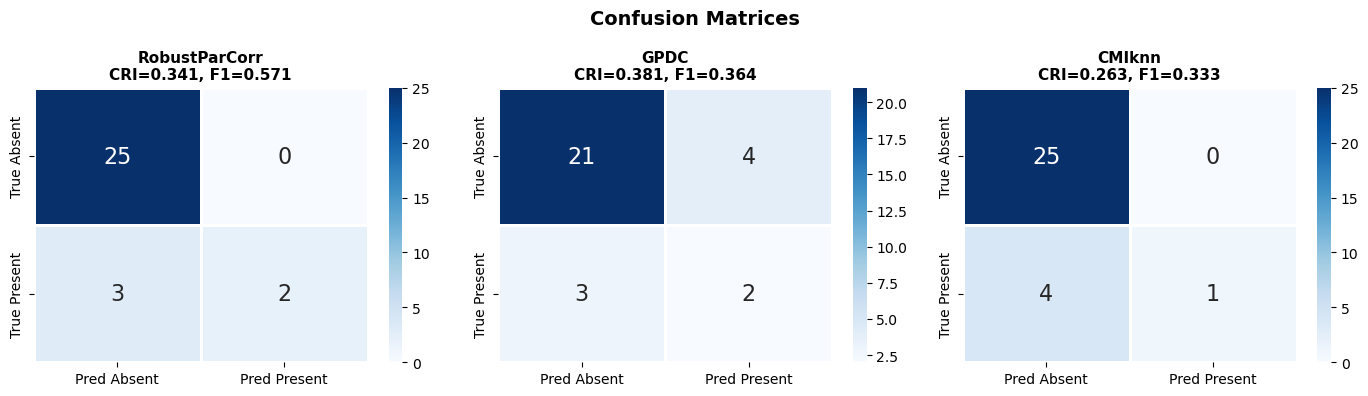

In [57]:
# === PLOT 5: Confusion matrices side by side ===
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, name in enumerate(['RobustParCorr', 'GPDC', 'CMIknn']):
    r = all_ci_results[name]
    cm = np.array([[r['TN'], r['FP']], [r['FN'], r['TP']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Absent', 'Pred Present'],
                yticklabels=['True Absent', 'True Present'],
                annot_kws={'size': 16}, ax=axes[idx], linewidths=1, linecolor='white')
    axes[idx].set_title(f"{name}\nCRI={r['CRI_TS']:.3f}, F1={r['F1']:.3f}", 
                        fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_confusion_matrices.png"), dpi=150)
plt.show()

CRI_TS is useful as a threshold-free ranking metric for comparing CI tests. In this experiment, it correctly ranked GPDC > ParCorr > CMIknn, matching the precision-based ranking. Its main advantage over F1/precision is that it doesn't depend on the choice of α — it uses the raw p-values directly.

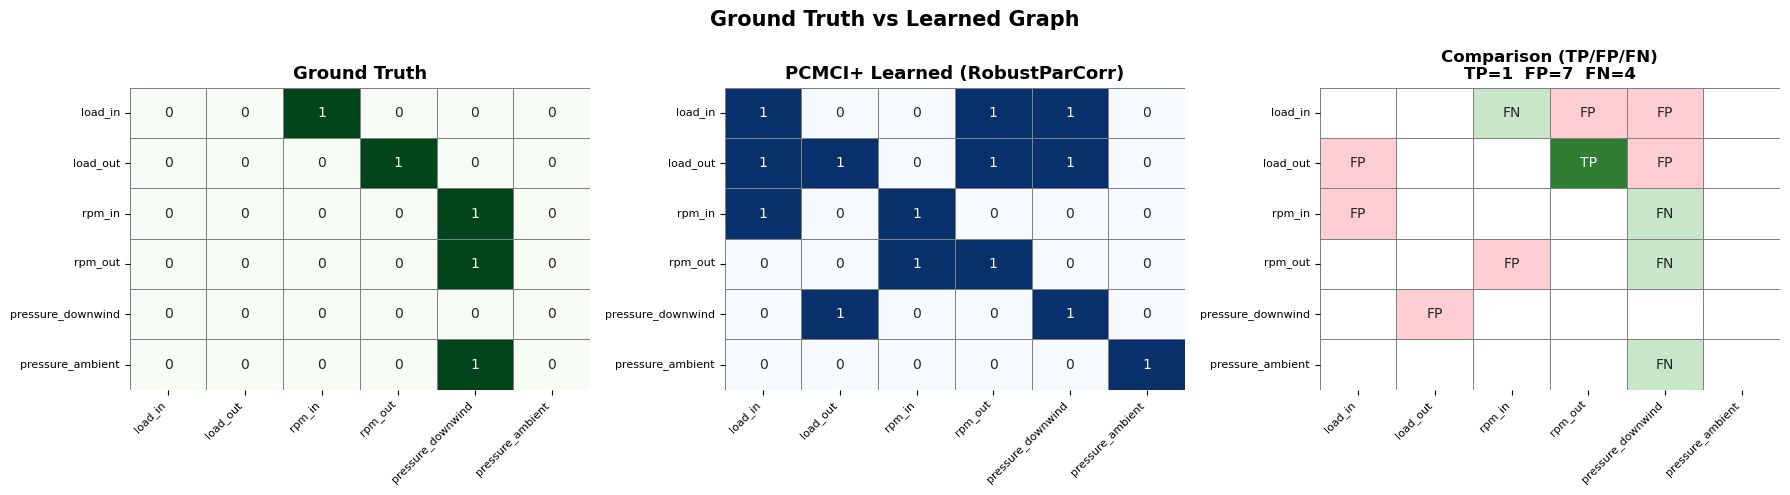


Edge                                       Found?  Min p-value
--------------------------------------------------------------
             load_in → rpm_in                  ✗     0.000000
            load_out → rpm_out                 ✓     0.000000
              rpm_in → pressure_downwind        ✗     0.160000
             rpm_out → pressure_downwind        ✗     0.322000
    pressure_ambient → pressure_downwind        ✗     0.388000


In [58]:
# === Ground Truth vs Learned Graph ===
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

d = len(available_vars)

# Build comparison matrix
display = np.zeros((d, d))
annot_text = np.full((d, d), '', dtype=object)

for i in range(d):
    for j in range(d):
        if i == j: continue
        is_true = gt_adj[i, j] == 1
        is_learned = learned_adj[i, j] == 1
        
        if is_true and is_learned:       # TP
            display[i, j] = 2
            annot_text[i, j] = 'TP'
        elif not is_true and is_learned:  # FP
            display[i, j] = -1
            annot_text[i, j] = 'FP'
        elif is_true and not is_learned:  # FN
            display[i, j] = 1
            annot_text[i, j] = 'FN'
        else:                             # TN
            display[i, j] = 0
            annot_text[i, j] = ''

cmap_custom = ListedColormap(['#FFCDD2', '#FFFFFF', '#C8E6C9', '#2E7D32'])
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5], cmap_custom.N)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ground truth
sns.heatmap(gt_adj, annot=True, fmt='d', cmap='Greens', vmin=0, vmax=1, cbar=False,
            xticklabels=available_vars, yticklabels=available_vars, ax=axes[0],
            linewidths=0.5, linecolor='gray')
axes[0].set_title('Ground Truth', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(available_vars, rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(available_vars, rotation=0, fontsize=8)

# Learned
sns.heatmap(learned_adj, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=1, cbar=False,
            xticklabels=available_vars, yticklabels=available_vars, ax=axes[1],
            linewidths=0.5, linecolor='gray')
axes[1].set_title('PCMCI+ Learned (RobustParCorr)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(available_vars, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(available_vars, rotation=0, fontsize=8)

# TP/FP/FN comparison
sns.heatmap(display, annot=annot_text, fmt='s', cmap=cmap_custom, norm=norm,
            cbar=False, xticklabels=available_vars, yticklabels=available_vars,
            ax=axes[2], linewidths=0.5, linecolor='gray')
axes[2].set_title(f'Comparison (TP/FP/FN)\nTP={int(((gt_adj[~np.eye(d,dtype=bool)].flatten()==1)&(learned_adj[~np.eye(d,dtype=bool)].flatten()==1)).sum())}  '
                   f'FP={int(((gt_adj[~np.eye(d,dtype=bool)].flatten()==0)&(learned_adj[~np.eye(d,dtype=bool)].flatten()==1)).sum())}  '
                   f'FN={int(((gt_adj[~np.eye(d,dtype=bool)].flatten()==1)&(learned_adj[~np.eye(d,dtype=bool)].flatten()==0)).sum())}',
                   fontsize=12, fontweight='bold')
axes[2].set_xticklabels(available_vars, rotation=45, ha='right', fontsize=8)
axes[2].set_yticklabels(available_vars, rotation=0, fontsize=8)

plt.suptitle('Ground Truth vs Learned Graph', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_gt_vs_learned.png'), dpi=150, bbox_inches='tight')
plt.show()

# Edge-by-edge detail
gt_edges_set = set(tuple(e) for e in GT_EDGES)
print(f"\n{'Edge':<40} {'Found?':>8} {'Min p-value':>12}")
print('-' * 62)
for src, tgt in GT_EDGES:
    i, j = available_vars.index(src), available_vars.index(tgt)
    found = learned_adj[i, j] == 1
    min_p = min(p_matrix[i, j, tau] for tau in range(1, 6))
    symbol = '✓' if found else '✗'
    print(f"  {src:>18} → {tgt:<16} {symbol:>8} {min_p:>12.6f}")

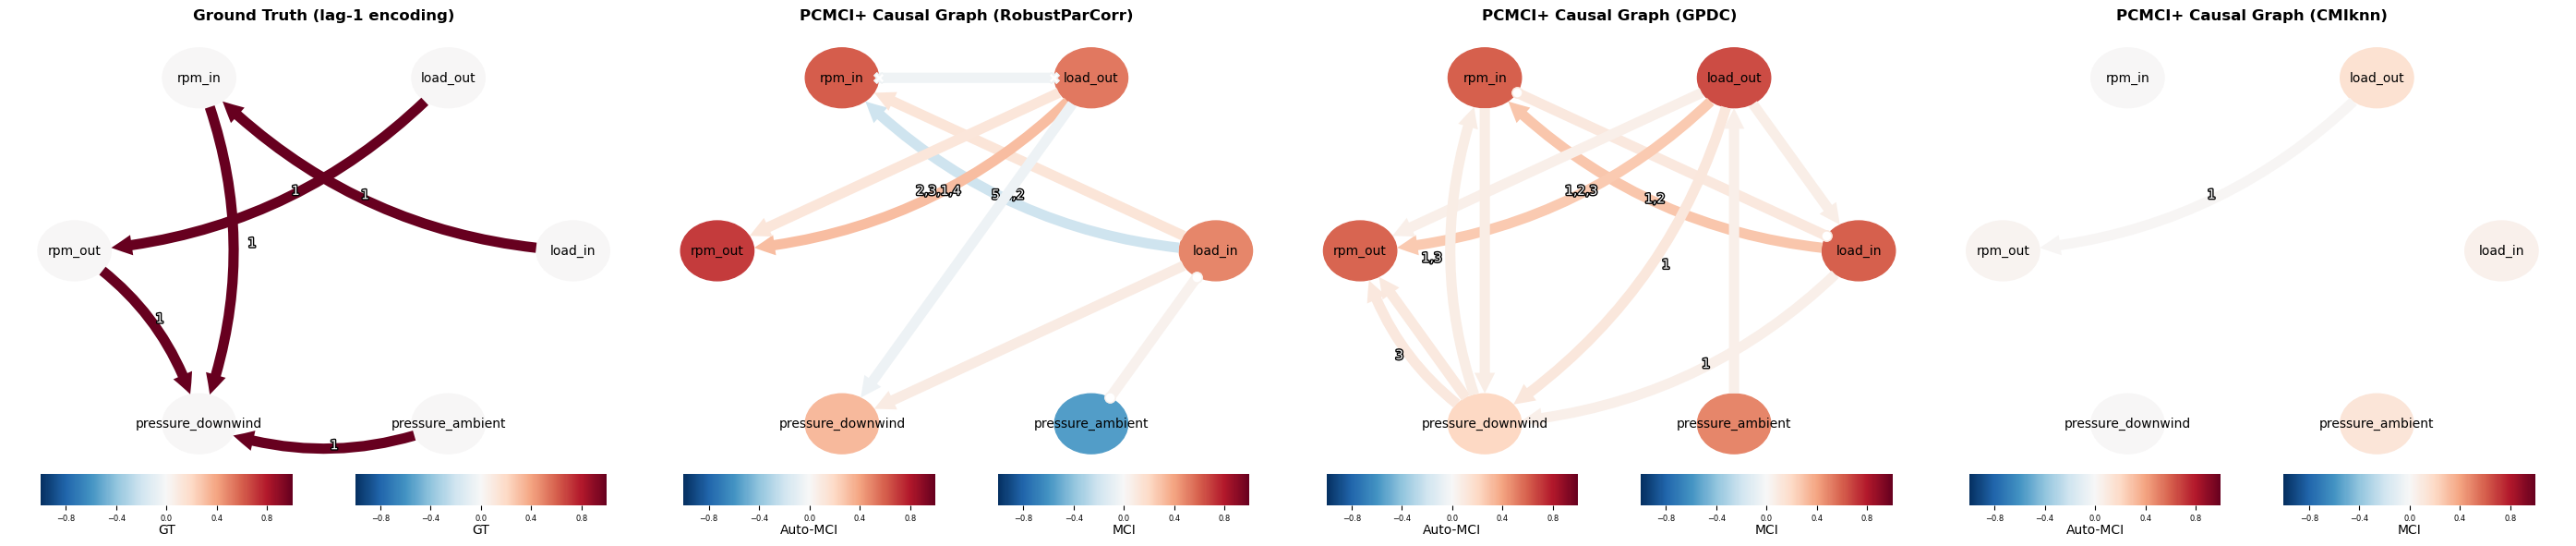

In [59]:
# === Ground Truth + 3 learned graphs in same Tigramite style ===
import os
import numpy as np
import matplotlib.pyplot as plt
from tigramite import plotting as tp

os.makedirs(OUTPUT_DIR, exist_ok=True)

d = len(available_vars)
tau_max = TAU_MAX  # same tau_max used in PCMCI+

# ------------------------------------------------------------------
# Build Tigramite-style ground-truth graph tensor (lag-1 encoding)
# ------------------------------------------------------------------
gt_graph_tig = np.empty((d, d, tau_max + 1), dtype=object)
gt_graph_tig[:] = ""

gt_val_tig = np.zeros((d, d, tau_max + 1), dtype=float)

for src, tgt in GT_EDGES:
    if src in available_vars and tgt in available_vars:
        i = available_vars.index(src)
        j = available_vars.index(tgt)
        gt_graph_tig[i, j, 1] = "-->"   # encode as directed lag-1 edge
        gt_val_tig[i, j, 1] = 1.0       # just for coloring/visibility

# ------------------------------------------------------------------
# Plot 4 panels: GT + ParCorr + GPDC + CMIknn
# ------------------------------------------------------------------
panels = [("Ground Truth", {"graph": gt_graph_tig, "val_matrix": gt_val_tig})] + \
         [(m, all_ci_results[m]) for m in ["RobustParCorr", "GPDC", "CMIknn"]]

fig, axes = plt.subplots(1, 4, figsize=(28, 6))

for ax, (name, obj) in zip(axes, panels):
    tp.plot_graph(
        graph=obj["graph"],
        val_matrix=obj["val_matrix"],
        var_names=available_vars,
        fig_ax=(fig, ax),
        link_colorbar_label='MCI' if name != "Ground Truth" else 'GT',
        node_colorbar_label='Auto-MCI' if name != "Ground Truth" else 'GT'
    )
    
    if name == "Ground Truth":
        ax.set_title("Ground Truth (lag-1 encoding)", fontweight='bold', fontsize=12)
    else:
        ax.set_title(f"PCMCI+ Causal Graph ({name})", fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_groundtruth_plus_3methods_tigramite_style.png'),
            dpi=150, bbox_inches='tight')
plt.show()

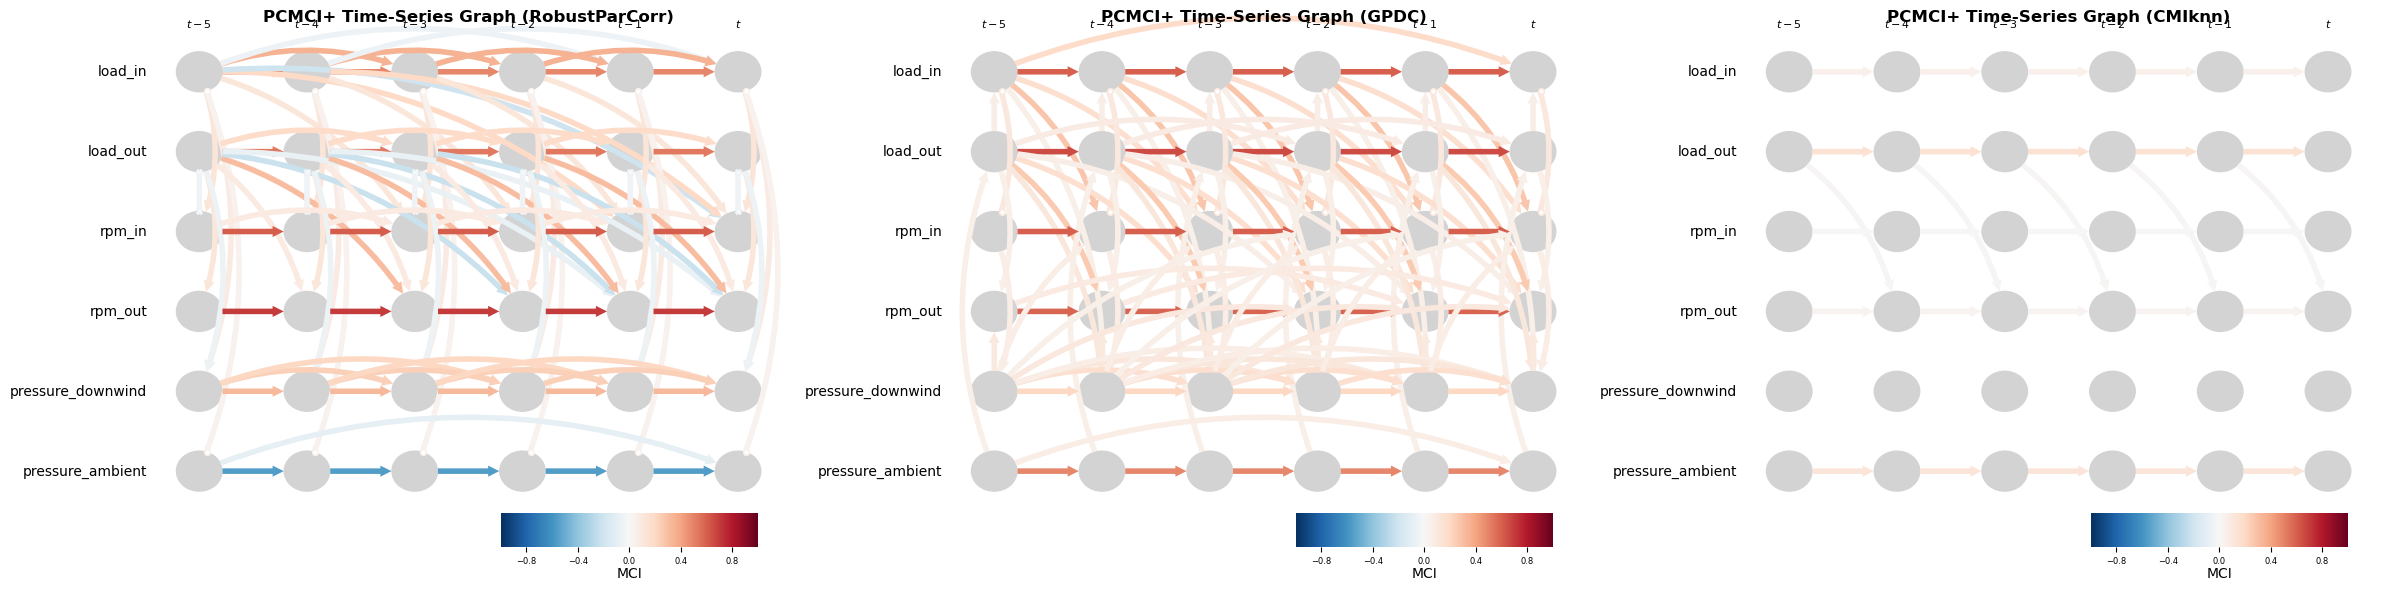

In [60]:
# === Plot time-series causal graphs (lag-aware) for the 3 methods ===
import os
import matplotlib.pyplot as plt
from tigramite import plotting as tp

os.makedirs(OUTPUT_DIR, exist_ok=True)

methods_order = ["RobustParCorr", "GPDC", "CMIknn"]

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for ax, method in zip(axes, methods_order):
    res = all_ci_results[method]
    
    tp.plot_time_series_graph(
        graph=res['graph'],
        val_matrix=res['val_matrix'],
        var_names=available_vars,
        fig_ax=(fig, ax),
        link_colorbar_label='MCI'
    )
    
    ax.set_title(f'PCMCI+ Time-Series Graph ({method})', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_pcmciplus_time_series_graphs_3_methods.png'),
            dpi=150, bbox_inches='tight')
plt.show()